<a href="https://colab.research.google.com/github/AntonyAroni/TELECOM-X--PART-2/blob/main/Telecom_par_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Extracción

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.preprocessing import StandardScaler, MinMaxScaler

from scipy import stats

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score


from sklearn.metrics import accuracy_score, precision_score, recall_score

import os

In [59]:
df = pd.read_csv('telecomx_cleaned_data.csv')

print(df.head())


   customerID  Churn  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  0002-ORFBO      0       0              0        1           1       9   
1  0003-MKNFE      0       1              0        0           0       9   
2  0004-TLHLJ      1       1              0        0           0       4   
3  0011-IGKFF      1       1              1        1           0      13   
4  0013-EXCHZ      1       0              1        1           0       3   

   PhoneService  PaperlessBilling  Charges.Monthly  ...  \
0             1                 1             65.6  ...   
1             1                 0             59.9  ...   
2             1                 1             73.9  ...   
3             1                 1             98.0  ...   
4             1                 1             83.9  ...   

   TechSupport_No internet service  StreamingTV_1  \
0                            False           True   
1                            False          False   
2                            

Eliminación de columna que no se usará

In [3]:
df_new = df.drop('customerID', axis=1)
print(df_new.columns)

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_1',
       'OnlineSecurity_No internet service', 'OnlineBackup_1',
       'OnlineBackup_No internet service', 'DeviceProtection_1',
       'DeviceProtection_No internet service', 'TechSupport_1',
       'TechSupport_No internet service', 'StreamingTV_1',
       'StreamingTV_No internet service', 'StreamingMovies_1',
       'StreamingMovies_No internet service', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [4]:
print(df_new.dtypes)

Churn                                      int64
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
Charges.Monthly                          float64
Charges.Total                            float64
Cuentas_Diarias                          float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_1                            bool
OnlineSecurity_No internet service          bool
OnlineBackup_1                              bool
OnlineBackup_No internet service            bool
DeviceProtection_1                          bool
DeviceProtection_No 

Conversión a valores numéricos (no necesario, pero recomendado)

In [5]:
bool_columns = df_new.select_dtypes(include=['bool']).columns
print(f"Columnas booleanas encontradas: {list(bool_columns)}")


Columnas booleanas encontradas: ['MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_1', 'OnlineSecurity_No internet service', 'OnlineBackup_1', 'OnlineBackup_No internet service', 'DeviceProtection_1', 'DeviceProtection_No internet service', 'TechSupport_1', 'TechSupport_No internet service', 'StreamingTV_1', 'StreamingTV_No internet service', 'StreamingMovies_1', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [6]:
df_new[bool_columns] = df_new[bool_columns].astype(int)
print("\nTipos de datos después de la conversión:")
print(df_new.dtypes)


Tipos de datos después de la conversión:
Churn                                      int64
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
Charges.Monthly                          float64
Charges.Total                            float64
Cuentas_Diarias                          float64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_1                           int64
OnlineSecurity_No internet service         int64
OnlineBackup_1                             int64
OnlineBackup_No internet service           int64
DeviceProtection_1         

## Proporcion de Cliente sque cancelaron en relación con los que permanecieron activos:

In [7]:
churn_counts = df_new['Churn'].value_counts()
churn_percentages = df_new['Churn'].value_counts(normalize=True) * 100

# Crear un DataFrame con los resultados
churn_distribution = pd.DataFrame({
    'Cantidad': churn_counts,
    'Porcentaje': churn_percentages
})

churn_distribution.index = ['No canceló (0)', 'Canceló (1)']

print("=== DISTRIBUCIÓN DE CANCELACIONES ===\n")
print(churn_distribution)
print("\n" + "="*40)

=== DISTRIBUCIÓN DE CANCELACIONES ===

                Cantidad  Porcentaje
No canceló (0)      5398   74.280996
Canceló (1)         1869   25.719004



visualizacion

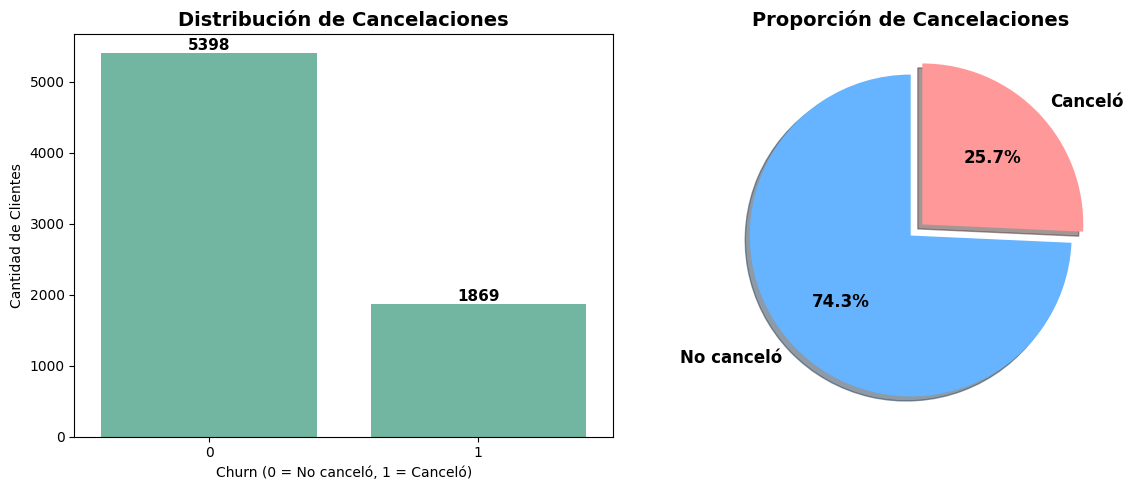

In [8]:
# Configurar el estilo
plt.style.use('default')
sns.set_palette("Set2")

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
ax1 = sns.countplot(data=df_new, x='Churn', ax=axes[0])
axes[0].set_title('Distribución de Cancelaciones', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = No canceló, 1 = Canceló)')
axes[0].set_ylabel('Cantidad de Clientes')

# Añadir etiquetas con los valores
for i in ax1.containers:
    ax1.bar_label(i, fmt='%d', fontsize=11, fontweight='bold')

# Gráfico de pastel
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)  # Resaltar la porción de cancelaciones
axes[1].pie(churn_counts.values,
            labels=['No canceló', 'Canceló'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            shadow=True,
            startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporción de Cancelaciones', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Verificar si hay desvalance:

In [9]:
churn_proporcion = df_new['Churn'].value_counts(normalize=True) * 100
if churn_proporcion[1] < 30:
    print(f"\n Hay un desbalance de clases: {churn_proporcion[1]:.2f}% de cancelaciones")
    print("   Esto puede afectar el rendimiento de los modelos predictivos.")
else:
    print(f"\n Las clases están relativamente balanceadas: {churn_proporcion[1]:.2f}% de cancelaciones")


 Hay un desbalance de clases: 25.72% de cancelaciones
   Esto puede afectar el rendimiento de los modelos predictivos.


In [10]:

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")

# Separar features y target
X = df_new.drop('Churn', axis=1)
y = df_new['Churn']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar un modelo simple para evaluar (usando class_weight por el desbalance)
modelo = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

# Predecir probabilidades y clases
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

print("="*60)
print(" ANÁLISIS DE DESBALANCE DE CLASES - CHURN")
print("="*60)

# 1. Distribución de clases
print("\n📊 1. DISTRIBUCIÓN DE CLASES:")
print("-"*40)
churn_dist = y.value_counts(normalize=True) * 100
print(f"Clientes que NO cancelaron (0): {churn_dist[0]:.2f}%")
print(f"Clientes que SÍ cancelaron (1): {churn_dist[1]:.2f}%")
print(f"Ratio (No cancelados/Cancelados): {churn_dist[0]/churn_dist[1]:.2f}:1")

# 2. Matriz de Confusión
print("\n📊 2. MATRIZ DE CONFUSIÓN:")
print("-"*40)
cm = confusion_matrix(y_test, y_pred)
print("                    Predicho")
print("                No(0)    Sí(1)")
print(f"Real No(0)     {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"Real Sí(1)     {cm[1,0]:6d}   {cm[1,1]:6d}")

# Calcular métricas de la matriz
tn, fp, fn, tp = cm.ravel()
print(f"\nDetalle:")
print(f"• Verdaderos Negativos (bien clasificados no cancelados): {tn}")
print(f"• Falsos Positivos (erróneamente clasificados como cancelación): {fp}")
print(f"• Falsos Negativos (cancelaciones no detectadas): {fn}")
print(f"• Verdaderos Positivos (cancelaciones bien detectadas): {tp}")

# 3. Classification Report (incluye F1-score)
print("\n📊 3. CLASSIFICATION REPORT (con F1-SCORE):")
print("-"*40)
print(classification_report(y_test, y_pred,
                          target_names=['No canceló', 'Sí canceló'],
                          digits=3))

# 4. ROC-AUC
print("\n📊 4. ROC-AUC SCORE:")
print("-"*40)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"(Interpretación: {roc_auc*100:.1f}% de capacidad para distinguir entre clases)")

# 5. Precision-Recall AUC
print("\n📊 5. PRECISION-RECALL AUC:")
print("-"*40)
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"Precision-Recall AUC: {pr_auc:.3f}")
print(f"(Interpretación: {pr_auc*100:.1f}% de precisión en la clase minoritaria)")



 ANÁLISIS DE DESBALANCE DE CLASES - CHURN

📊 1. DISTRIBUCIÓN DE CLASES:
----------------------------------------
Clientes que NO cancelaron (0): 74.28%
Clientes que SÍ cancelaron (1): 25.72%
Ratio (No cancelados/Cancelados): 2.89:1

📊 2. MATRIZ DE CONFUSIÓN:
----------------------------------------
                    Predicho
                No(0)    Sí(1)
Real No(0)        779      301
Real Sí(1)         71      303

Detalle:
• Verdaderos Negativos (bien clasificados no cancelados): 779
• Falsos Positivos (erróneamente clasificados como cancelación): 301
• Falsos Negativos (cancelaciones no detectadas): 71
• Verdaderos Positivos (cancelaciones bien detectadas): 303

📊 3. CLASSIFICATION REPORT (con F1-SCORE):
----------------------------------------
              precision    recall  f1-score   support

  No canceló      0.916     0.721     0.807      1080
  Sí canceló      0.502     0.810     0.620       374

    accuracy                          0.744      1454
   macro avg      0.7

visulaizacion

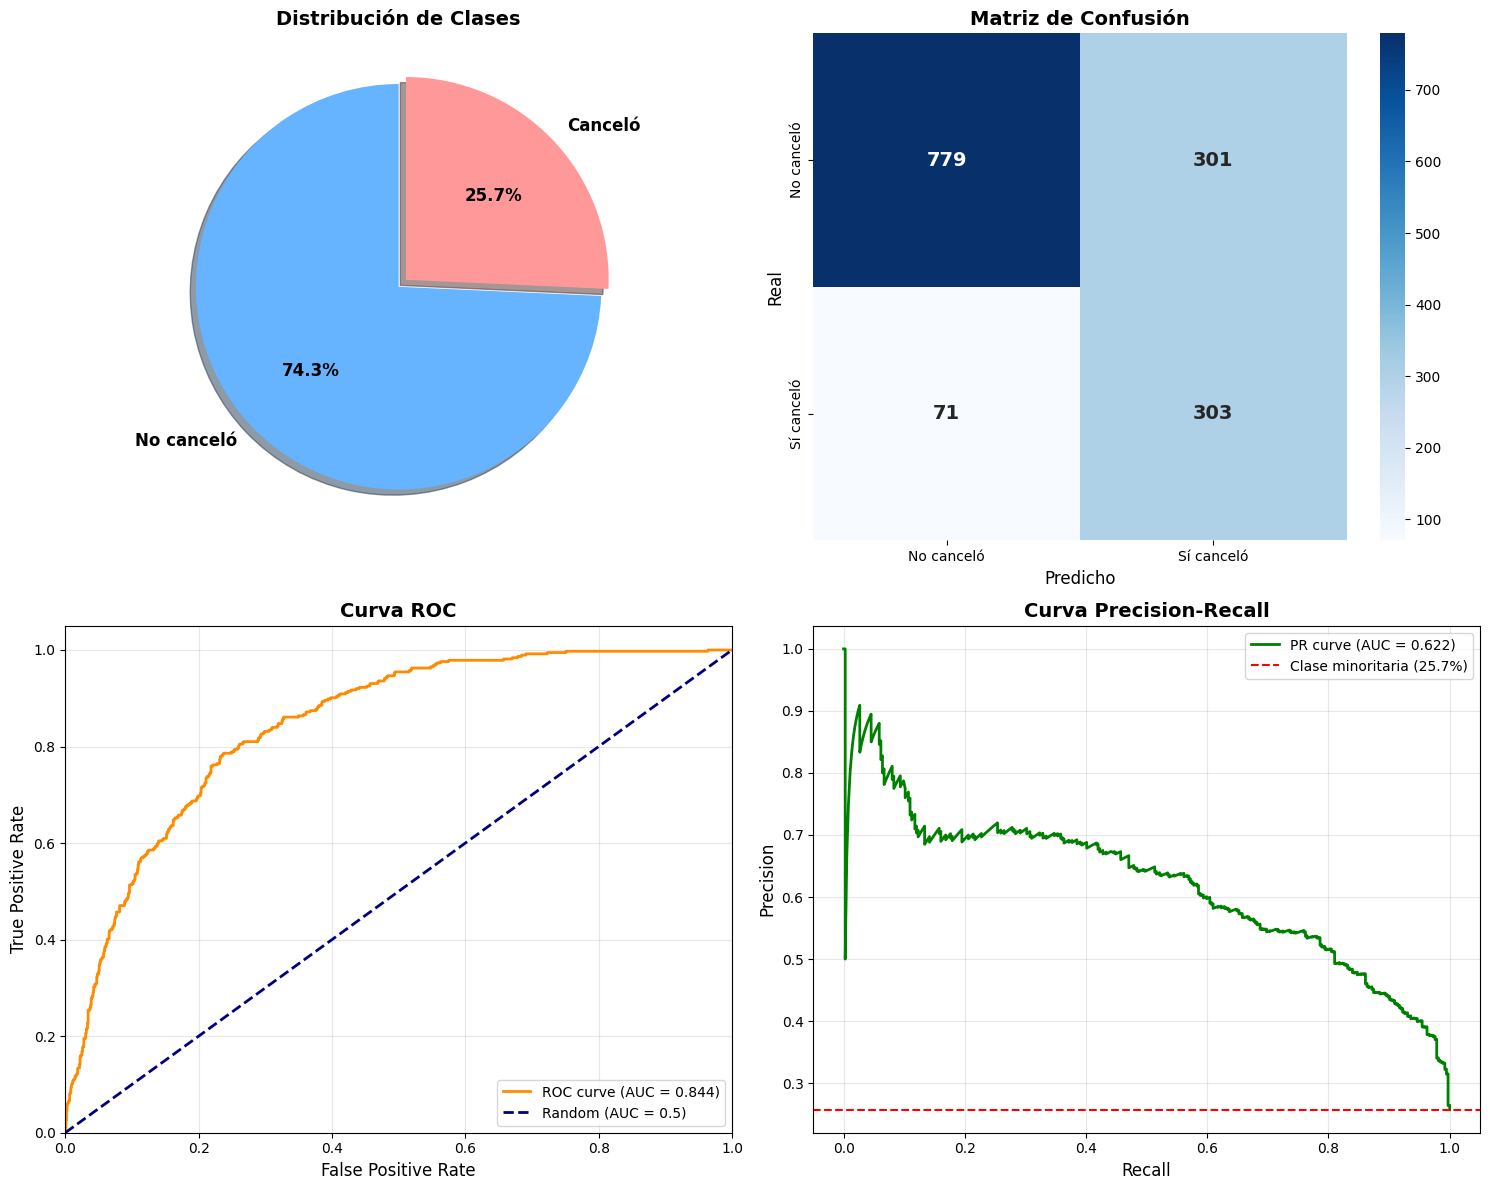

In [11]:
# 6. VISUALIZACIONES
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Distribución de clases
ax1 = axes[0, 0]
colors = ['#66b3ff', '#ff9999']
wedges, texts, autotexts = ax1.pie(churn_dist.values,
                                    labels=['No canceló', 'Canceló'],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    explode=(0, 0.05),
                                    shadow=True,
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Distribución de Clases', fontsize=14, fontweight='bold')

# Gráfico 2: Matriz de Confusión
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No canceló', 'Sí canceló'],
            yticklabels=['No canceló', 'Sí canceló'],
            ax=ax2, annot_kws={'size': 14, 'fontweight': 'bold'})
ax2.set_xlabel('Predicho', fontsize=12)
ax2.set_ylabel('Real', fontsize=12)
ax2.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')

# Gráfico 3: Curva ROC
ax3 = axes[1, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=12)
ax3.set_ylabel('True Positive Rate', fontsize=12)
ax3.set_title('Curva ROC', fontsize=14, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

# Gráfico 4: Curva Precision-Recall
ax4 = axes[1, 1]
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ax4.plot(recall, precision, color='green', lw=2,
         label=f'PR curve (AUC = {pr_auc:.3f})')
ax4.set_xlabel('Recall', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Curva Precision-Recall', fontsize=14, fontweight='bold')
ax4.axhline(y=churn_dist[1]/100, color='red', linestyle='--',
            label=f'Clase minoritaria ({churn_dist[1]:.1f}%)')
ax4.legend(loc="best")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Balanceo

In [12]:
# 1. Separar features y target
X = df_new.drop('Churn', axis=1)
y = df_new['Churn']

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print("="*60)
print(" SITUACIÓN ORIGINAL (TRAIN)")
print("="*60)
print(f"Total muestras train: {len(y_train)}")
print(f"Clase 0 (No canceló): {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.2f}%)")
print(f"Clase 1 (Sí canceló): {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.2f}%)")

 SITUACIÓN ORIGINAL (TRAIN)
Total muestras train: 5813
Clase 0 (No canceló): 4318 (74.28%)
Clase 1 (Sí canceló): 1495 (25.72%)


Oversampling con Smote

In [14]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Total muestras train después de SMOTE: {len(y_train_smote)}")
print(f"Clase 0 (No canceló): {sum(y_train_smote==0)} ({sum(y_train_smote==0)/len(y_train_smote)*100:.2f}%)")
print(f"Clase 1 (Sí canceló): {sum(y_train_smote==1)} ({sum(y_train_smote==1)/len(y_train_smote)*100:.2f}%)")

Total muestras train después de SMOTE: 8636
Clase 0 (No canceló): 4318 (50.00%)
Clase 1 (Sí canceló): 4318 (50.00%)


Comparativa

In [15]:
comparacion = pd.DataFrame({
    'Técnica': ['Original', 'SMOTE'],
    'Total muestras': [
        len(y_train),
        len(y_train_smote)
    ],
    'Clase 0 (No canceló)': [
        sum(y_train==0),
        sum(y_train_smote==0)
    ],
    'Clase 1 (Canceló)': [
        sum(y_train==1),
        sum(y_train_smote==1)
    ],
    '% Clase 0': [
        f"{(sum(y_train==0)/len(y_train)*100):.1f}%",
        f"{(sum(y_train_smote==0)/len(y_train_smote)*100):.1f}%"
    ],
    '% Clase 1': [
        f"{(sum(y_train==1)/len(y_train)*100):.1f}%",
        f"{(sum(y_train_smote==1)/len(y_train_smote)*100):.1f}%"
    ]
})

print("\n" + "="*60)
print(" COMPARACIÓN ORIGINAL VS SMOTE")
print("="*60)
print(comparacion.to_string(index=False))


 COMPARACIÓN ORIGINAL VS SMOTE
 Técnica  Total muestras  Clase 0 (No canceló)  Clase 1 (Canceló) % Clase 0 % Clase 1
Original            5813                  4318               1495     74.3%     25.7%
   SMOTE            8636                  4318               4318     50.0%     50.0%


Visualziacion

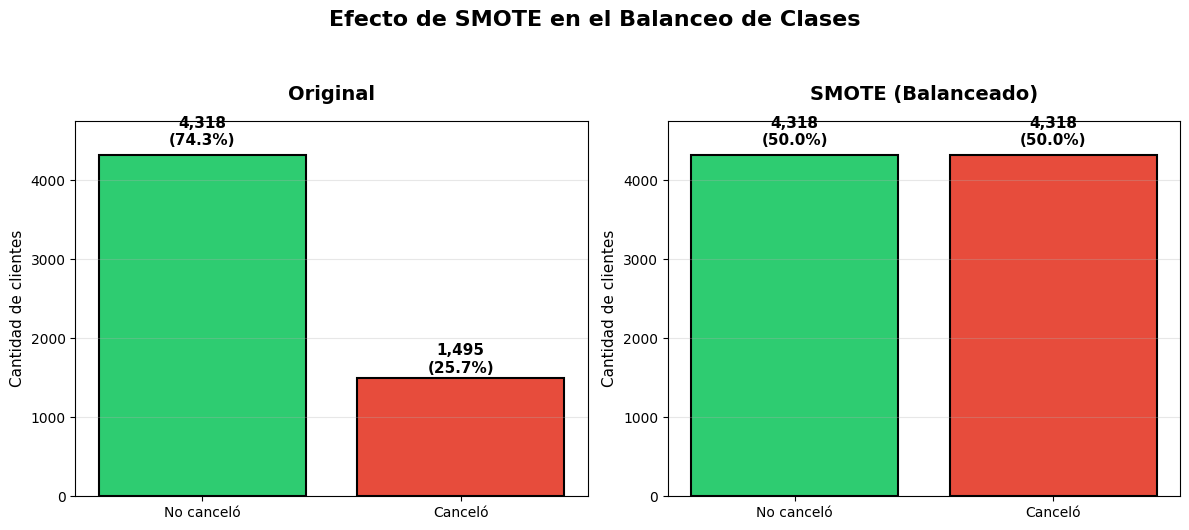

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datos = [
    (y_train, 'Original'),
    (y_train_smote, 'SMOTE (Balanceado)')
]

for i, (y_data, titulo) in enumerate(datos):
    ax = axes[i]
    counts = [sum(y_data==0), sum(y_data==1)]
    bars = ax.bar(['No canceló', 'Canceló'], counts,
                  color=['#2ecc71', '#e74c3c'],
                  edgecolor='black',
                  linewidth=1.5)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Cantidad de clientes', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        porcentaje = (count/len(y_data)*100)
        ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.02),
                f'{count:,}\n({porcentaje:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

max_count = max(sum(y_train), sum(y_train_smote))
for ax in axes:
    ax.set_ylim(0, max_count * 1.1)

plt.suptitle('Efecto de SMOTE en el Balanceo de Clases',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Normalización o Estandarización (si e snecesario)

In [17]:
# Usar los datos balanceados con SMOTE
X_balanceado = X_train_smote
y_balanceado = y_train_smote

# Identificar columnas numéricas continuas (las que necesitan escalado)
columnas_continuas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
columnas_binarias = [col for col in X_balanceado.columns if col not in columnas_continuas]

print("="*70)
print(" ANÁLISIS DE NECESIDAD DE ESCALADO")
print("="*70)

print("\n 1. RANGOS DE VARIABLES CONTINUAS:")
print("-"*50)
for col in columnas_continuas:
    print(f"\n{col}:")
    print(f"  Mínimo: {X_balanceado[col].min():.2f}")
    print(f"  Máximo: {X_balanceado[col].max():.2f}")
    print(f"  Rango: {X_balanceado[col].max() - X_balanceado[col].min():.2f}")
    print(f"  Media: {X_balanceado[col].mean():.2f}")
    print(f"  Desviación: {X_balanceado[col].std():.2f}")

print("\n" + "="*70)
print(" COMPARACIÓN DE ESCALAS")
print("="*70)

escalas = pd.DataFrame({
    'Variable': columnas_continuas,
    'Mínimo': [X_balanceado[col].min() for col in columnas_continuas],
    'Máximo': [X_balanceado[col].max() for col in columnas_continuas],
    'Rango': [X_balanceado[col].max() - X_balanceado[col].min() for col in columnas_continuas],
    'Desviación': [X_balanceado[col].std() for col in columnas_continuas]
})
print("\n", escalas.to_string(index=False))


 ANÁLISIS DE NECESIDAD DE ESCALADO

 1. RANGOS DE VARIABLES CONTINUAS:
--------------------------------------------------

tenure:
  Mínimo: 0.00
  Máximo: 72.00
  Rango: 72.00
  Media: 27.61
  Desviación: 23.96

Charges.Monthly:
  Mínimo: 18.25
  Máximo: 118.65
  Rango: 100.40
  Media: 68.27
  Desviación: 28.65

Charges.Total:
  Mínimo: 18.80
  Máximo: 8684.80
  Rango: 8666.00
  Media: 2045.65
  Desviación: 2172.86

Cuentas_Diarias:
  Mínimo: 0.61
  Máximo: 3.96
  Rango: 3.35
  Media: 2.28
  Desviación: 0.95

 COMPARACIÓN DE ESCALAS

        Variable    Mínimo   Máximo       Rango  Desviación
         tenure  0.000000   72.000   72.000000   23.960760
Charges.Monthly 18.250000  118.650  100.400000   28.647318
  Charges.Total 18.800000 8684.800 8666.000000 2172.856932
Cuentas_Diarias  0.608333    3.955    3.346667    0.954911


visualización

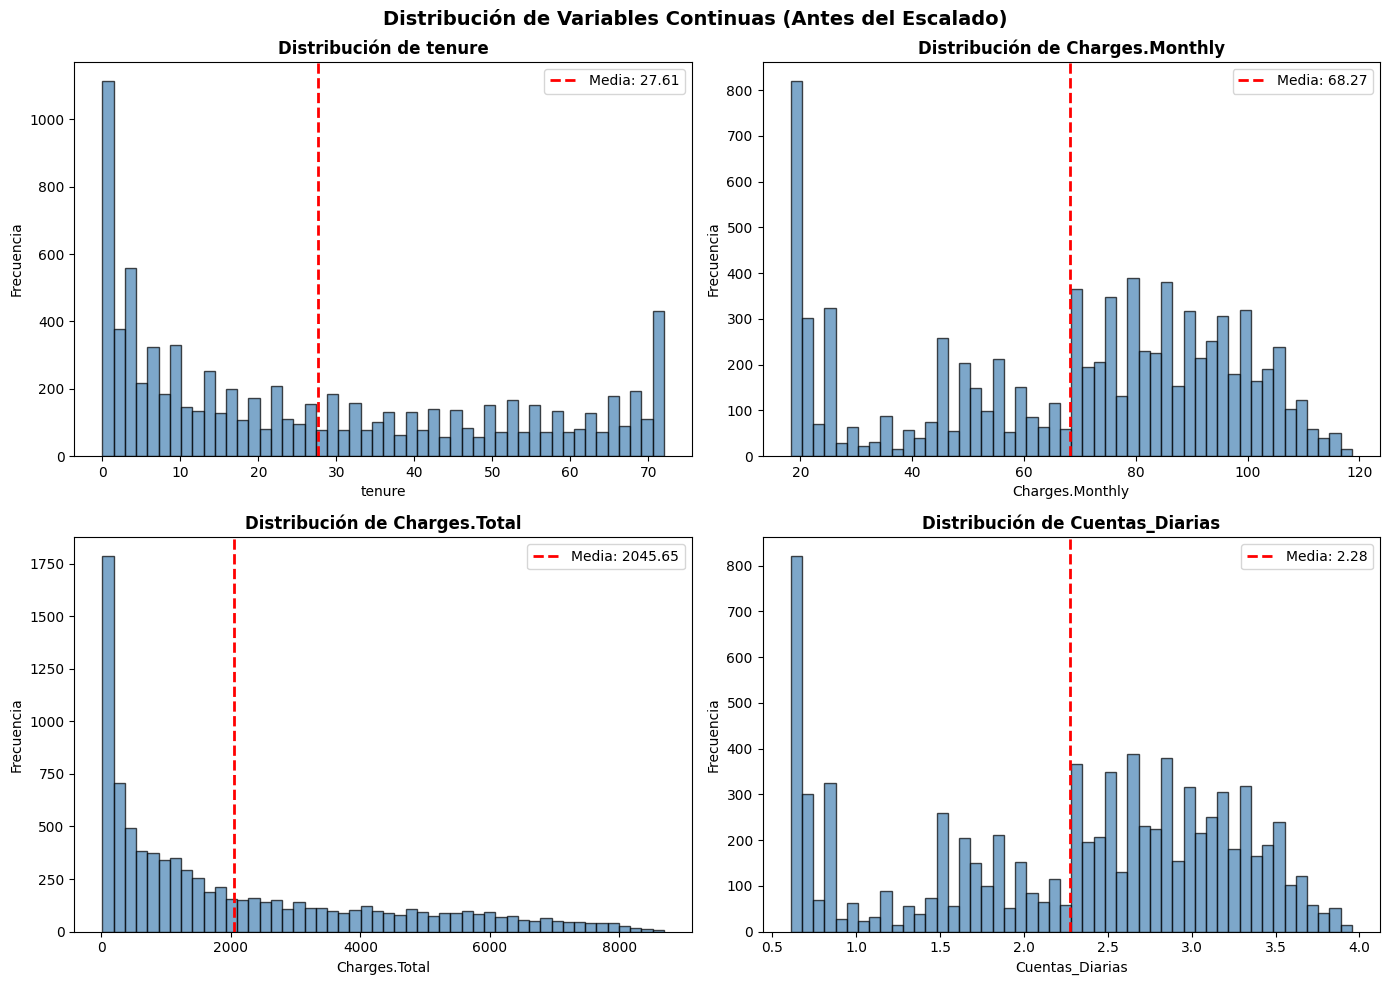

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(columnas_continuas):
    ax = axes[i]
    ax.hist(X_balanceado[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Distribución de {col}', fontweight='bold', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.axvline(X_balanceado[col].mean(), color='red', linestyle='--',
               linewidth=2, label=f'Media: {X_balanceado[col].mean():.2f}')
    ax.legend()

plt.suptitle('Distribución de Variables Continuas (Antes del Escalado)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 DECISIÓN DE ESCALADO SEGÚN MODELO


Modelo                  | ¿Requiere escalado? | Razón
------------------------|---------------------|-----------------------------------------------
KNN                     | ✅ SÍ               | Basado en distancias euclidianas
SVM                     | ✅ SÍ               | Sensible a la magnitud de características
Regresión Logística     | ✅ SÍ               | Gradiente sensible a escalas
Redes Neuronales        | ✅ SÍ               | Convergencia más rápida con escalado
Decision Tree           | ❌ NO               | Basado en umbrales, no en distancias
Random Forest           | ❌ NO               | Ensemble de árboles
XGBoost                 | ❌ NO               | Gradient boosting con árboles

## Análisis de Correlación

Matriz de Correlación

In [19]:
correlacion = df_new.corr()

print(f"Dimensiones de la matriz de correlación: {correlacion.shape}")
print(f"Total de variables: {len(correlacion.columns)}")

Dimensiones de la matriz de correlación: (32, 32)
Total de variables: 32


Obtener correlaciones con Churn y ordenar de mayor a menor

In [20]:

corr_con_churn = correlacion['Churn'].sort_values(ascending=False)

print("="*70)
print(" CORRELACIONES CON CHURN (ordenadas de mayor a menor)")
print("="*70)

# Separar en positivas y negativas para mejor visualización
positivas = corr_con_churn[corr_con_churn > 0].sort_values(ascending=False)
negativas = corr_con_churn[corr_con_churn < 0].sort_values()

print("\n CORRELACIONES POSITIVAS (a mayor valor, más probable la cancelación):")
print("-"*50)
for var, corr in positivas.items():
    if var != 'Churn':  # Excluir la propia variable Churn
        print(f"{var:40s} {corr:+.4f}")

print("\n CORRELACIONES NEGATIVAS (a mayor valor, menos probable la cancelación):")
print("-"*50)
for var, corr in negativas.items():
    print(f"{var:40s} {corr:+.4f}")

 CORRELACIONES CON CHURN (ordenadas de mayor a menor)

 CORRELACIONES POSITIVAS (a mayor valor, más probable la cancelación):
--------------------------------------------------
InternetService_Fiber optic              +0.3009
PaymentMethod_Electronic check           +0.2946
Cuentas_Diarias                          +0.1899
Charges.Monthly                          +0.1899
PaperlessBilling                         +0.1867
SeniorCitizen                            +0.1467
StreamingTV_1                            +0.0624
StreamingMovies_1                        +0.0606
MultipleLines_Yes                        +0.0393
PhoneService                             +0.0126

 CORRELACIONES NEGATIVAS (a mayor valor, menos probable la cancelación):
--------------------------------------------------
tenure                                   -0.3441
Contract_Two year                        -0.2951
InternetService_No                       -0.2241
TechSupport_No internet service          -0.2241
OnlineBackup

### Top 10 variables más correlacionadas (positivas y negativas)

In [21]:
top_positivas = positivas.head(6)[1:]  # Excluimos Churn, tomamos 5
top_negativas = negativas.head(5)

print("\n" + "="*70)
print(" TOP VARIABLES CORRELACIONADAS CON CHURN")
print("="*70)

print("\nTOP 5 CORRELACIONES POSITIVAS (mayor probabilidad de cancelación):")
for i, (var, corr) in enumerate(top_positivas.items(), 1):
    print(f"{i:2d}. {var:40s} {corr:+.4f}")

print("\nTOP 5 CORRELACIONES NEGATIVAS (menor probabilidad de cancelación):")
for i, (var, corr) in enumerate(top_negativas.items(), 1):
    print(f"{i:2d}. {var:40s} {corr:+.4f}")


 TOP VARIABLES CORRELACIONADAS CON CHURN

TOP 5 CORRELACIONES POSITIVAS (mayor probabilidad de cancelación):
 1. InternetService_Fiber optic              +0.3009
 2. PaymentMethod_Electronic check           +0.2946
 3. Cuentas_Diarias                          +0.1899
 4. Charges.Monthly                          +0.1899
 5. PaperlessBilling                         +0.1867

TOP 5 CORRELACIONES NEGATIVAS (menor probabilidad de cancelación):
 1. tenure                                   -0.3441
 2. Contract_Two year                        -0.2951
 3. InternetService_No                       -0.2241
 4. TechSupport_No internet service          -0.2241
 5. OnlineBackup_No internet service         -0.2241


Visualización

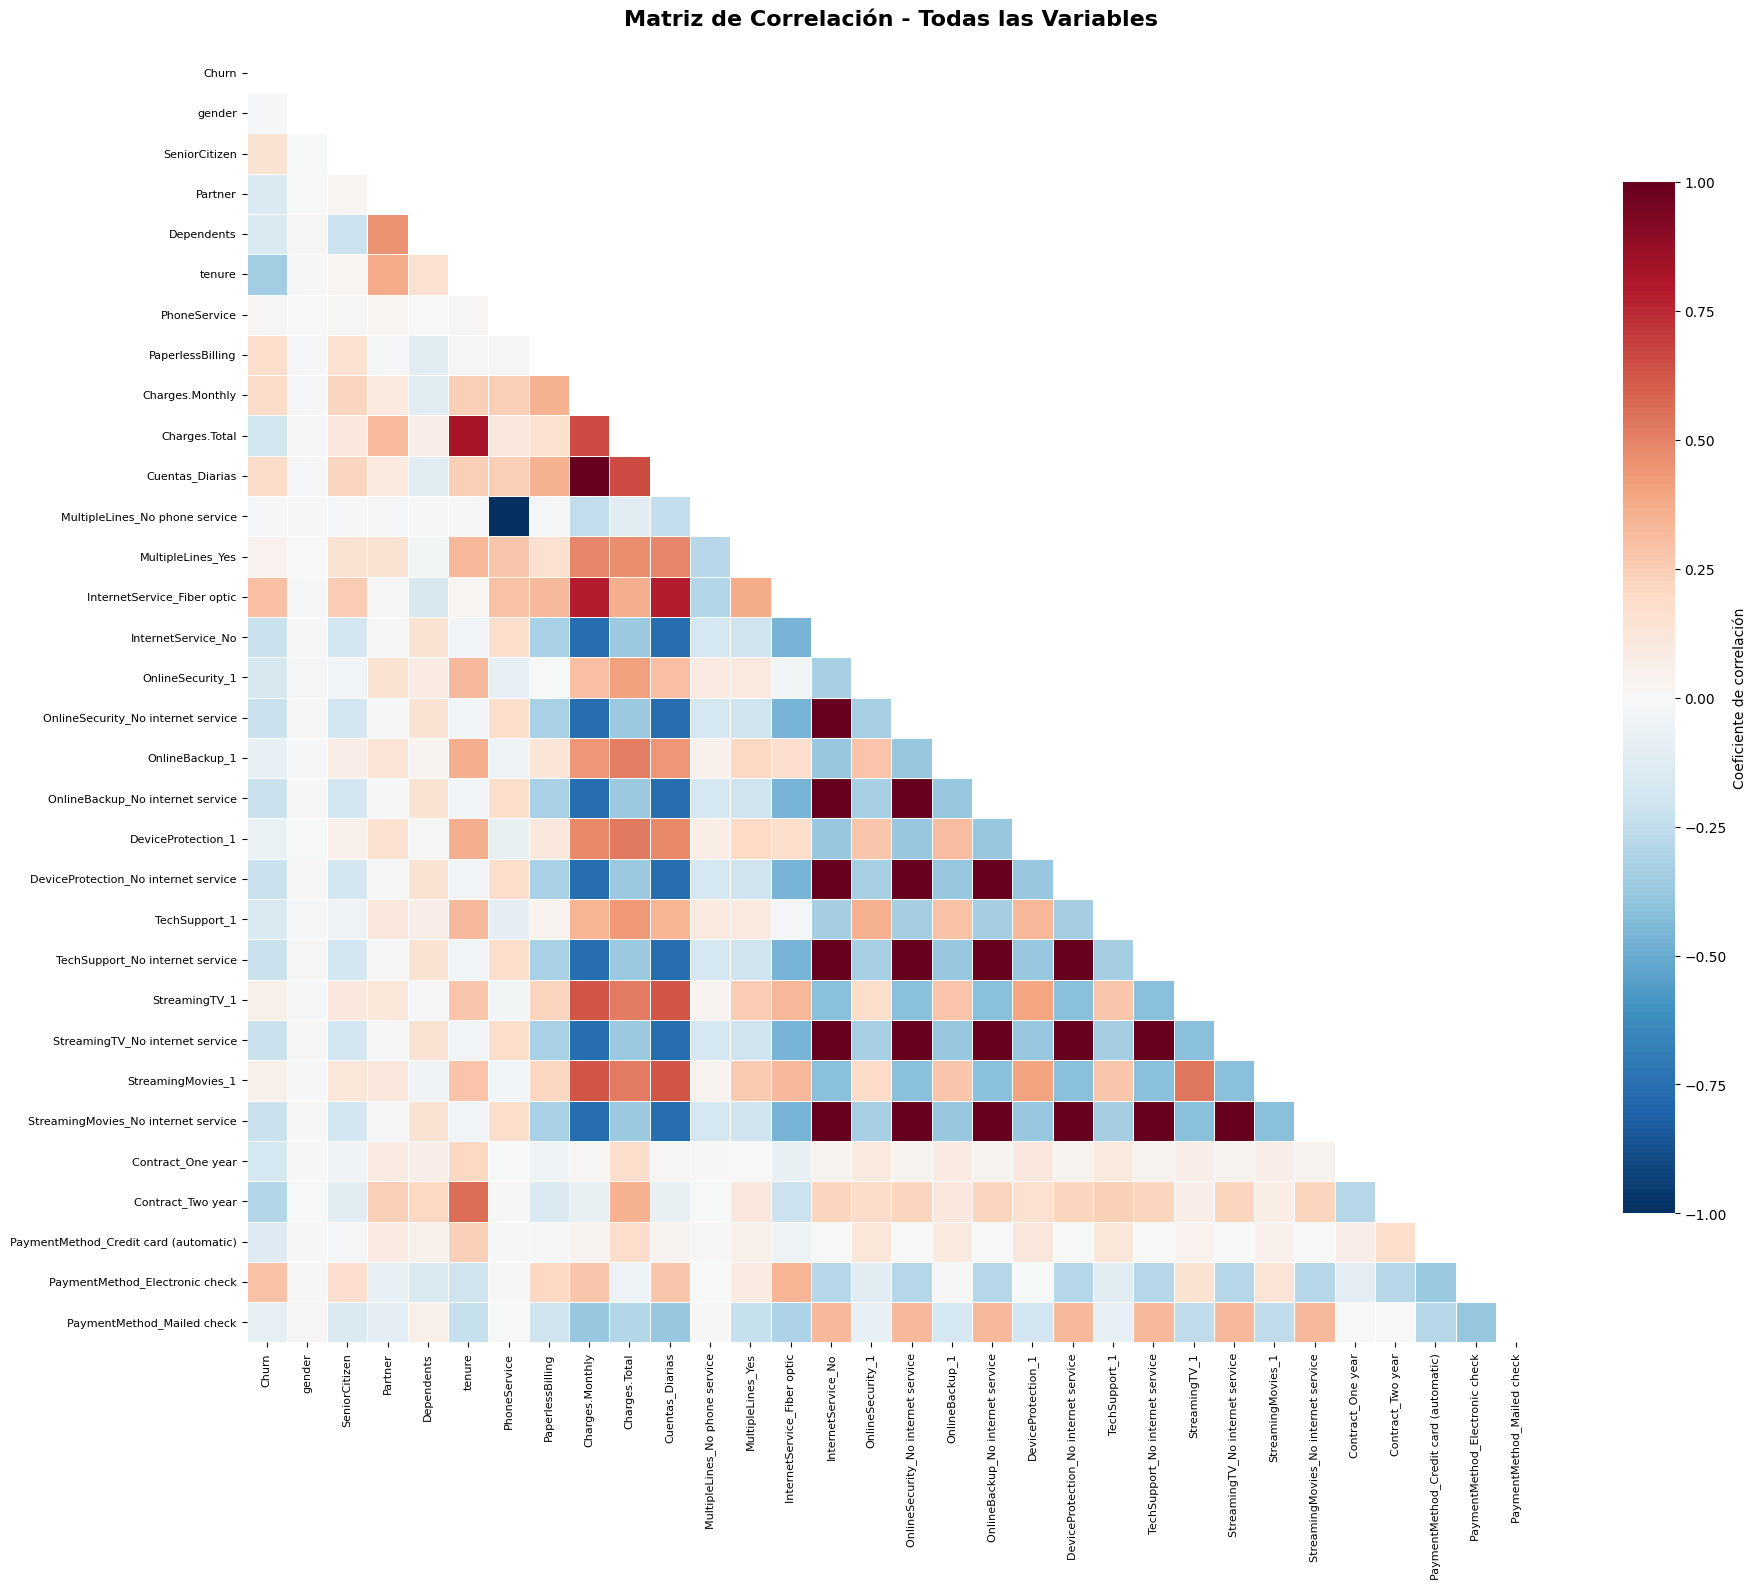

In [22]:
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlacion, dtype=bool))

# Heatmap de correlación
sns.heatmap(correlacion,
            mask=mask,
            annot=False,
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlación"})

plt.title('Matriz de Correlación - Todas las Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Análisis Dirigido

#### ANÁLISIS: TIEMPO DE CONTRATO (TENURE) VS CANCELACIÓN

In [23]:
plt.style.use('default')
sns.set_palette("husl")

print("="*70)
print(" ANÁLISIS 1: TIEMPO DE CONTRATO (TENURE) VS CANCELACIÓN")
print("="*70)

# Estadísticas descriptivas por grupo
print("\n📊 ESTADÍSTICAS DE TENURE POR GRUPO:")
print("-"*50)

estadisticas_tenure = df_new.groupby('Churn')['tenure'].describe()
print(estadisticas_tenure)

# Prueba estadística (t-test) para verificar si la diferencia es significativa
t_stat, p_value = stats.ttest_ind(
    df_new[df_new['Churn']==0]['tenure'],
    df_new[df_new['Churn']==1]['tenure']
)

print(f"\n📈 PRUEBA T-TEST:")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.4e}")
print(f"   {'✅ Diferencia significativa' if p_value < 0.05 else '❌ No hay diferencia significativa'}")

 ANÁLISIS 1: TIEMPO DE CONTRATO (TENURE) VS CANCELACIÓN

📊 ESTADÍSTICAS DE TENURE POR GRUPO:
--------------------------------------------------
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5398.0  37.321045  24.178367  0.0  14.0  37.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

📈 PRUEBA T-TEST:
   t-statistic: 31.2348
   p-value: 4.4662e-201
   ✅ Diferencia significativa


#### Tenure por Churn

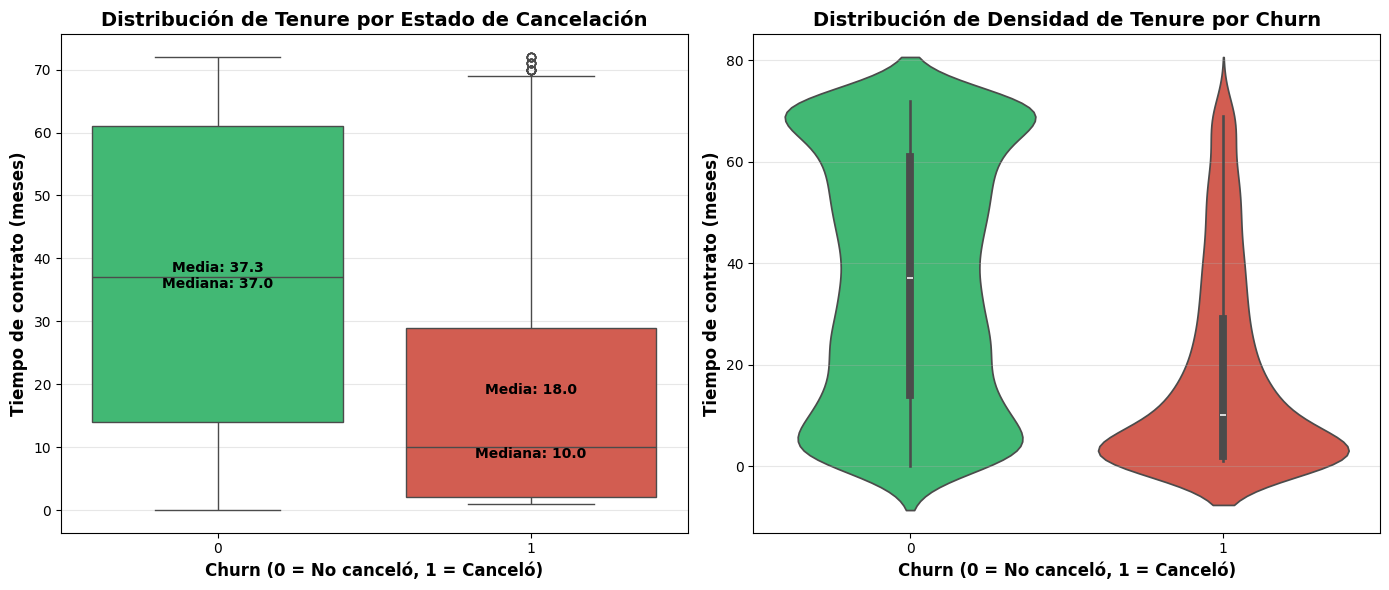

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
ax1 = axes[0]
sns.boxplot(data=df_new, x='Churn', y='tenure', ax=ax1, palette=['#2ecc71', '#e74c3c'])
ax1.set_xlabel('Churn (0 = No canceló, 1 = Canceló)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tiempo de contrato (meses)', fontsize=12, fontweight='bold')
ax1.set_title('Distribución de Tenure por Estado de Cancelación', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Añadir estadísticas al boxplot
means = df_new.groupby('Churn')['tenure'].mean()
medians = df_new.groupby('Churn')['tenure'].median()
for i, (mean, median) in enumerate(zip(means, medians)):
    ax1.text(i, mean, f'Media: {mean:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax1.text(i, median, f'Mediana: {median:.1f}', ha='center', va='top', fontweight='bold', fontsize=10)

# Violin plot (muestra la distribución completa)
ax2 = axes[1]
sns.violinplot(data=df_new, x='Churn', y='tenure', ax=ax2, palette=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Churn (0 = No canceló, 1 = Canceló)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tiempo de contrato (meses)', fontsize=12, fontweight='bold')
ax2.set_title('Distribución de Densidad de Tenure por Churn', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Histogramas superpuestos

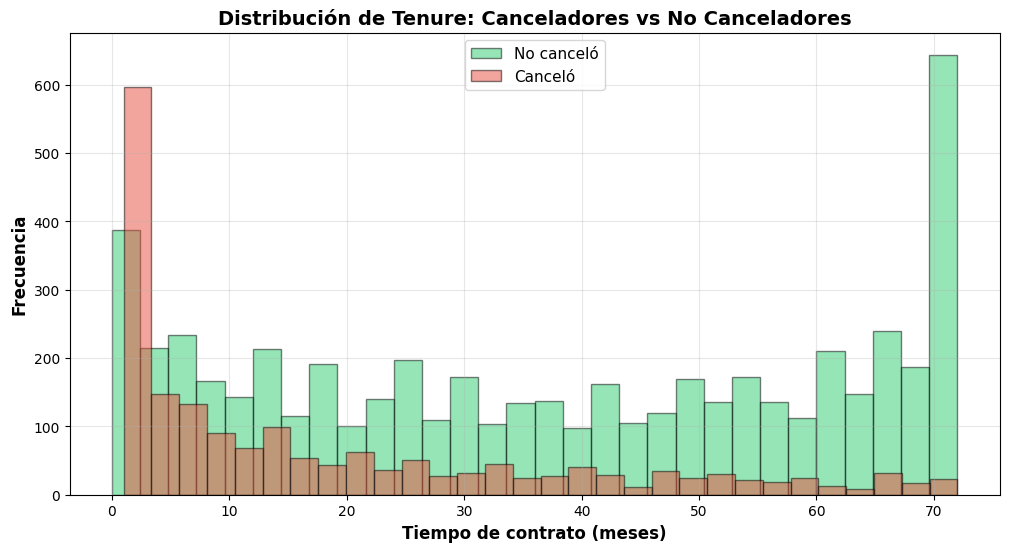

In [25]:
plt.figure(figsize=(12, 6))

# Histogramas
plt.hist(df_new[df_new['Churn']==0]['tenure'], bins=30, alpha=0.5,
         label='No canceló', color='#2ecc71', edgecolor='black')
plt.hist(df_new[df_new['Churn']==1]['tenure'], bins=30, alpha=0.5,
         label='Canceló', color='#e74c3c', edgecolor='black')

plt.xlabel('Tiempo de contrato (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Frecuencia', fontsize=12, fontweight='bold')
plt.title('Distribución de Tenure: Canceladores vs No Canceladores', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

#### Tasa de cancelación por rangos de tenure

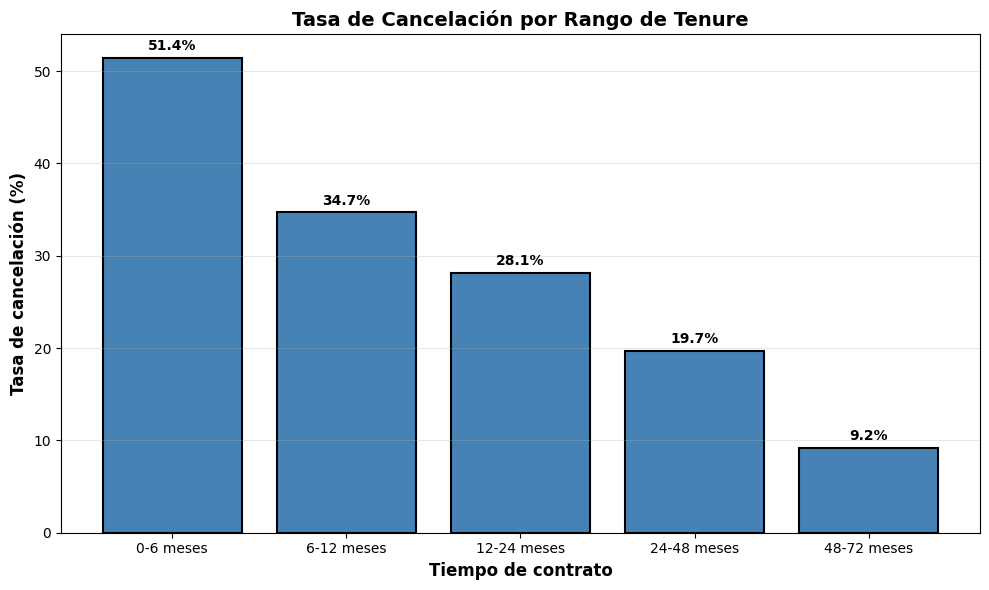

In [26]:
# Crear rangos de tenure
df_new['tenure_range'] = pd.cut(df_new['tenure'],
                                  bins=[0, 6, 12, 24, 48, 72],
                                  labels=['0-6 meses', '6-12 meses', '12-24 meses',
                                          '24-48 meses', '48-72 meses'])

# Calcular tasa de cancelación por rango
churn_rate_by_tenure = df_new.groupby('tenure_range')['Churn'].mean().reset_index()
churn_rate_by_tenure['Churn'] = churn_rate_by_tenure['Churn'] * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(churn_rate_by_tenure['tenure_range'],
               churn_rate_by_tenure['Churn'],
               color='steelblue', edgecolor='black', linewidth=1.5)

plt.xlabel('Tiempo de contrato', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de cancelación (%)', fontsize=12, fontweight='bold')
plt.title('Tasa de Cancelación por Rango de Tenure', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Añadir etiquetas
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### ANÁLISIS: GASTO TOTAL VS CANCELACIÓN

In [27]:
print("\n" + "="*70)
print(" ANÁLISIS 2: GASTO TOTAL (CHARGES.TOTAL) VS CANCELACIÓN")
print("="*70)

# Estadísticas descriptivas por grupo
print("\n📊 ESTADÍSTICAS DE CHARGES.TOTAL POR GRUPO:")
print("-"*50)

estadisticas_gasto = df_new.groupby('Churn')['Charges.Total'].describe()
print(estadisticas_gasto)

# Prueba estadística
t_stat, p_value = stats.ttest_ind(
    df_new[df_new['Churn']==0]['Charges.Total'],
    df_new[df_new['Churn']==1]['Charges.Total']
)

print(f"\n📈 PRUEBA T-TEST:")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.4e}")
print(f"   {'✅ Diferencia significativa' if p_value < 0.05 else '❌ No hay diferencia significativa'}")


 ANÁLISIS 2: GASTO TOTAL (CHARGES.TOTAL) VS CANCELACIÓN

📊 ESTADÍSTICAS DE CHARGES.TOTAL POR GRUPO:
--------------------------------------------------
        count         mean          std    min      25%       50%       75%  \
Churn                                                                         
0      5398.0  2538.098546  2328.561578  18.80  571.075  1663.625  4237.275   
1      1869.0  1531.796094  1890.822994  18.85  134.500   703.550  2331.300   

           max  
Churn           
0      8672.45  
1      8684.80  

📈 PRUEBA T-TEST:
   t-statistic: 16.8573
   p-value: 1.4182e-62
   ✅ Diferencia significativa


#### Boxplot de Gasto Total por Churn

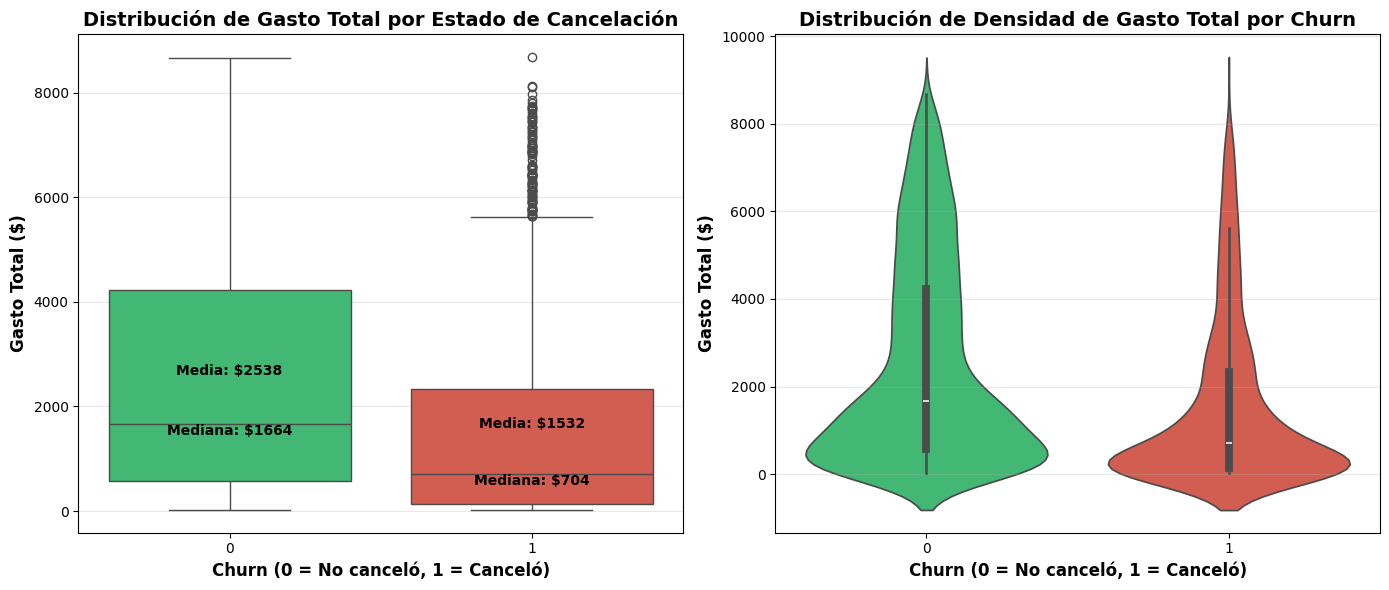

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
ax1 = axes[0]
sns.boxplot(data=df_new, x='Churn', y='Charges.Total', ax=ax1, palette=['#2ecc71', '#e74c3c'])
ax1.set_xlabel('Churn (0 = No canceló, 1 = Canceló)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gasto Total ($)', fontsize=12, fontweight='bold')
ax1.set_title('Distribución de Gasto Total por Estado de Cancelación', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Añadir estadísticas
means = df_new.groupby('Churn')['Charges.Total'].mean()
medians = df_new.groupby('Churn')['Charges.Total'].median()
for i, (mean, median) in enumerate(zip(means, medians)):
    ax1.text(i, mean, f'Media: ${mean:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax1.text(i, median, f'Mediana: ${median:.0f}', ha='center', va='top', fontweight='bold', fontsize=10)

# Violin plot
ax2 = axes[1]
sns.violinplot(data=df_new, x='Churn', y='Charges.Total', ax=ax2, palette=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Churn (0 = No canceló, 1 = Canceló)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gasto Total ($)', fontsize=12, fontweight='bold')
ax2.set_title('Distribución de Densidad de Gasto Total por Churn', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

####  Scatter plot Tenure vs Gasto Total coloreado por Churn

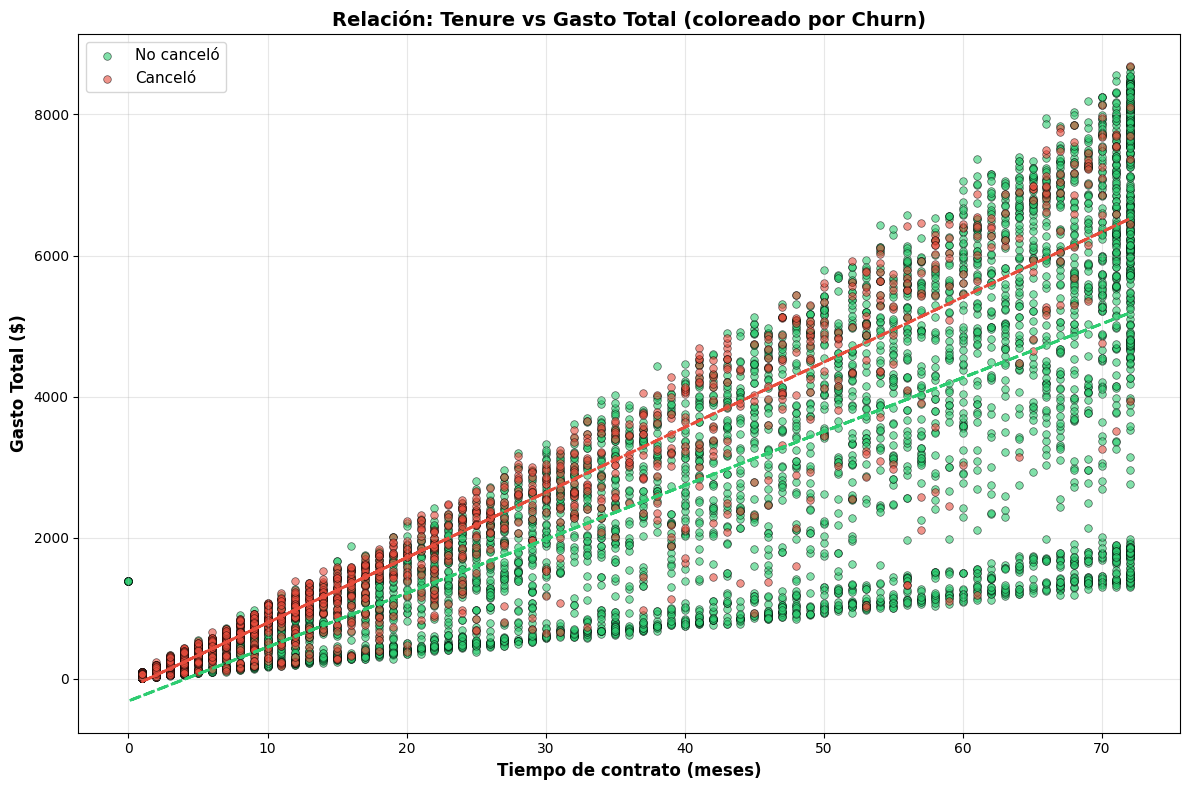

In [29]:
plt.figure(figsize=(12, 8))

# Scatter plot
colors = {0: '#2ecc71', 1: '#e74c3c'}
for churn in [0, 1]:
    subset = df_new[df_new['Churn'] == churn]
    plt.scatter(subset['tenure'], subset['Charges.Total'],
               c=colors[churn], label=f'{"No canceló" if churn==0 else "Canceló"}',
               alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('Tiempo de contrato (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Gasto Total ($)', fontsize=12, fontweight='bold')
plt.title('Relación: Tenure vs Gasto Total (coloreado por Churn)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Añadir líneas de tendencia
from numpy.polynomial.polynomial import polyfit

for churn in [0, 1]:
    subset = df_new[df_new['Churn'] == churn]
    if len(subset) > 1:
        b, m = polyfit(subset['tenure'], subset['Charges.Total'], 1)
        plt.plot(subset['tenure'], b + m * subset['tenure'],
                color=colors[churn], linewidth=2, linestyle='--')

plt.tight_layout()
plt.show()

#### Tasa de cancelación por rangos de gasto

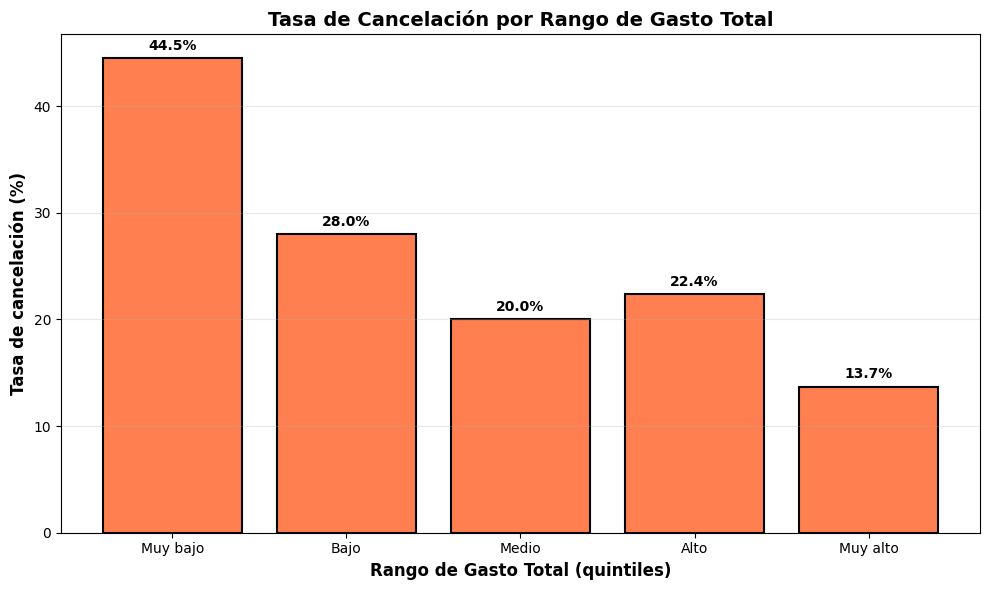

In [30]:
# Crear rangos de gasto
df_new['gasto_range'] = pd.qcut(df_new['Charges.Total'],
                                  q=5,
                                  labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

# Calcular tasa de cancelación por rango de gasto
churn_rate_by_gasto = df_new.groupby('gasto_range')['Churn'].mean().reset_index()
churn_rate_by_gasto['Churn'] = churn_rate_by_gasto['Churn'] * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(churn_rate_by_gasto['gasto_range'],
               churn_rate_by_gasto['Churn'],
               color='coral', edgecolor='black', linewidth=1.5)

plt.xlabel('Rango de Gasto Total (quintiles)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de cancelación (%)', fontsize=12, fontweight='bold')
plt.title('Tasa de Cancelación por Rango de Gasto Total', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Añadir etiquetas
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Análsiis Combinado

Corregir usuarios con Tenure = 0, nuevos usuarios

In [31]:
df_new['categoria_cliente'] = pd.cut(df_new['tenure'],
                                      bins=[0, 12, 48, 72],
                                      labels=['Nuevo (0-12 meses)',
                                              'Regular (12-48 meses)',
                                              'Leal (48-72 meses)'],
                                      include_lowest=True)  # Esto incluye el 0

# Verificar que ya no hay NaN
print(f"NaN después de corrección: {df_new['categoria_cliente'].isna().sum()}")
print("\nDistribución de categorías:")
print(df_new['categoria_cliente'].value_counts())

# Ver los clientes con tenure=0 ahora
print("\nClientes con tenure=0 ahora en categoría:")
print(df_new[df_new['tenure'] == 0][['tenure', 'categoria_cliente', 'Churn']].head(11))

NaN después de corrección: 0

Distribución de categorías:
categoria_cliente
Regular (12-48 meses)    2693
Leal (48-72 meses)       2309
Nuevo (0-12 meses)       2265
Name: count, dtype: int64

Clientes con tenure=0 ahora en categoría:
      tenure   categoria_cliente  Churn
975        0  Nuevo (0-12 meses)      0
1775       0  Nuevo (0-12 meses)      0
1955       0  Nuevo (0-12 meses)      0
2075       0  Nuevo (0-12 meses)      0
2232       0  Nuevo (0-12 meses)      0
2308       0  Nuevo (0-12 meses)      0
2930       0  Nuevo (0-12 meses)      0
3134       0  Nuevo (0-12 meses)      0
3203       0  Nuevo (0-12 meses)      0
4169       0  Nuevo (0-12 meses)      0
5599       0  Nuevo (0-12 meses)      0


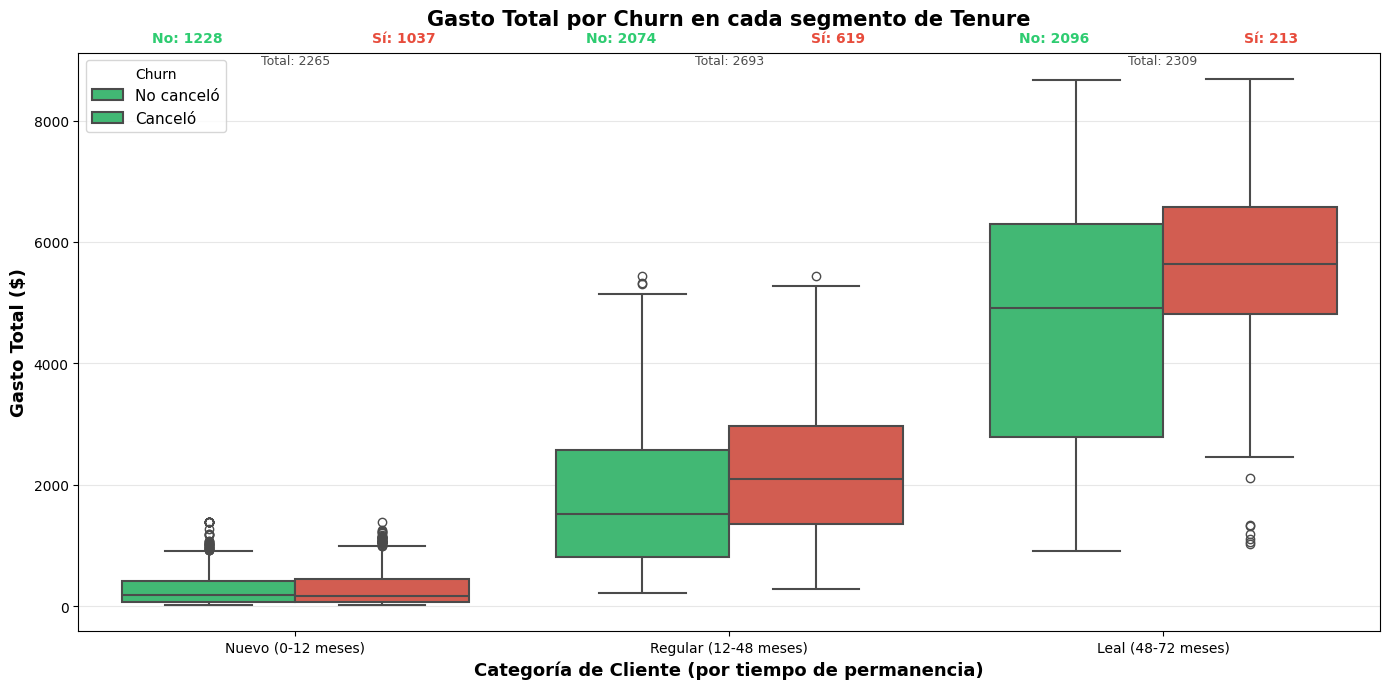

In [32]:
plt.figure(figsize=(14, 7))

# Boxplots agrupados
ax = sns.boxplot(data=df_new, x='categoria_cliente', y='Charges.Total', hue='Churn',
                 palette=['#2ecc71', '#e74c3c'],
                 linewidth=1.5)

plt.xlabel('Categoría de Cliente (por tiempo de permanencia)', fontsize=13, fontweight='bold')
plt.ylabel('Gasto Total ($)', fontsize=13, fontweight='bold')
plt.title('Gasto Total por Churn en cada segmento de Tenure', fontsize=15, fontweight='bold', pad=20)
plt.legend(title='Churn', labels=['No canceló', 'Canceló'], fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Añadir tamaños de muestra
categorias = df_new['categoria_cliente'].cat.categories
for i, cat in enumerate(categorias):
    subset = df_new[df_new['categoria_cliente'] == cat]
    n_no = len(subset[subset['Churn']==0])
    n_si = len(subset[subset['Churn']==1])
    total = len(subset)

    # Texto con tamaños de muestra
    plt.text(i-0.25, plt.ylim()[1]*1.02, f'No: {n_no}',
             ha='center', fontsize=10, color='#2ecc71', fontweight='bold')
    plt.text(i+0.25, plt.ylim()[1]*1.02, f'Sí: {n_si}',
             ha='center', fontsize=10, color='#e74c3c', fontweight='bold')
    plt.text(i, plt.ylim()[1]*0.98, f'Total: {total}',
             ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

## Separación de Datos

Ya no hace falta porque se realizó al momento de realizar el proceso de balanceo: 80% para entrenamiento y 20% para prueba

In [33]:
# Para ENTRENAR (balanceado)
X_train_smote  # Features con SMOTE
y_train_smote  # Target balanceado 50/50

# Para EVALUAR (original)
X_test         # Features originales sin tocar
y_test         # Target original con 74/26

,Churn
4272,1
4764,1
5373,0
5070,1
5721,0
...,...
3150,1
1154,0
7163,1
1547,0


In [34]:
total_muestras = len(df_new)
train_samples = len(y_train)
test_samples = len(y_test)

print(f"Total dataset: {total_muestras} clientes")
print(f"Train (80%): {train_samples} clientes")
print(f"Test (20%): {test_samples} clientes")
print(f"Proporción train/test: {train_samples/total_muestras*100:.0f}/{test_samples/total_muestras*100:.0f}")

Total dataset: 7267 clientes
Train (80%): 5813 clientes
Test (20%): 1454 clientes
Proporción train/test: 80/20


## Creación de Modelos

### PREPARAR LOS DATOS CON Y SIN NORMALIZACIÓN

datos in normalizar

In [41]:

X_train_sin_norm = X_train_smote
X_test_sin_norm = X_test


datos normalizados

In [43]:
columnas_continuas = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
columnas_binarias = [col for col in X_train_smote.columns if col not in columnas_continuas]

X_train_norm = X_train_smote.copy()
X_test_norm = X_test.copy()

scaler = StandardScaler()
X_train_norm[columnas_continuas] = scaler.fit_transform(X_train_smote[columnas_continuas])
X_test_norm[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

print("\nEstadísticas después de normalizar (medias ≈ 0, std ≈ 1):")
print(X_train_norm[columnas_continuas].mean().round(2))
print(X_train_norm[columnas_continuas].std().round(2))


Estadísticas después de normalizar (medias ≈ 0, std ≈ 1):
tenure             0.0
Charges.Monthly    0.0
Charges.Total     -0.0
Cuentas_Diarias   -0.0
dtype: float64
tenure             1.0
Charges.Monthly    1.0
Charges.Total      1.0
Cuentas_Diarias    1.0
dtype: float64


### REGRESIÓN LOGÍSTICA CON NORMALIZACIÓN

In [46]:
rl_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rl_model.fit(X_train_norm, y_train_smote)

# Predicciones
y_pred_rl = rl_model.predict(X_test_norm)
y_pred_proba_rl = rl_model.predict_proba(X_test_norm)[:, 1]

evaluacion

In [52]:
# Evaluación
print("\MÉTRICAS DE EVALUACIÓN:")
print("-"*50)
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rl):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rl):.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rl, target_names=['No canceló', 'Canceló']))


\MÉTRICAS DE EVALUACIÓN:
--------------------------------------------------
ROC-AUC: 0.8326
F1-Score: 0.6073

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No canceló       0.88      0.82      0.85      1080
     Canceló       0.56      0.67      0.61       374

    accuracy                           0.78      1454
   macro avg       0.72      0.74      0.73      1454
weighted avg       0.79      0.78      0.78      1454



matriz de confusion

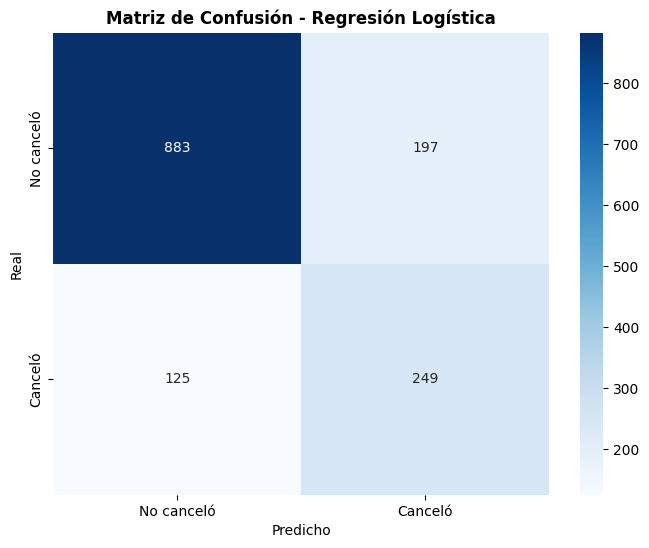

In [48]:
cm_rl = confusion_matrix(y_test, y_pred_rl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No canceló', 'Canceló'],
            yticklabels=['No canceló', 'Canceló'])
plt.title('Matriz de Confusión - Regresión Logística', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

### RANDOM FOREST SIN NORMALIZACIÓN

In [50]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train_sin_norm, y_train_smote)

# Predicciones
y_pred_rf = rf_model.predict(X_test_sin_norm)
y_pred_proba_rf = rf_model.predict_proba(X_test_sin_norm)[:, 1]

evaluacion

In [53]:

print("\nMÉTRICAS DE EVALUACIÓN:")
print("-"*50)
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf, target_names=['No canceló', 'Canceló']))



MÉTRICAS DE EVALUACIÓN:
--------------------------------------------------
ROC-AUC: 0.8156
F1-Score: 0.5505

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No canceló       0.85      0.83      0.84      1080
     Canceló       0.54      0.56      0.55       374

    accuracy                           0.76      1454
   macro avg       0.69      0.70      0.70      1454
weighted avg       0.77      0.76      0.77      1454



matriz de confusion

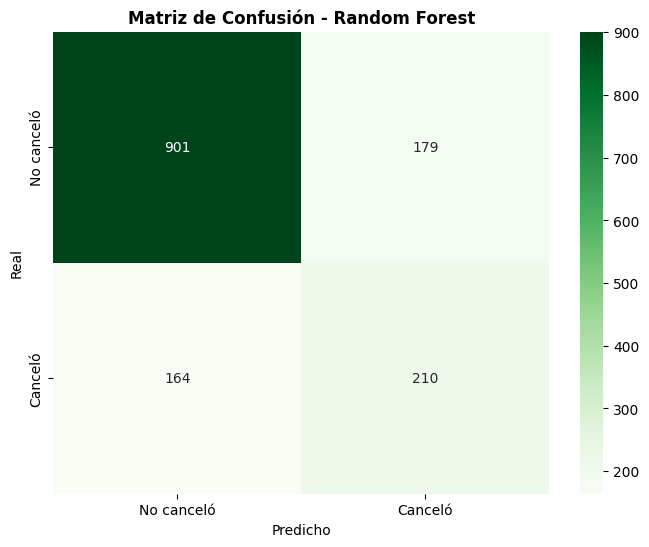

In [54]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No canceló', 'Canceló'],
            yticklabels=['No canceló', 'Canceló'])
plt.title('Matriz de Confusión - Random Forest', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

### COMPARACIÓN DE MODELOS

In [55]:
comparacion_modelos = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Normalización': ['Sí (StandardScaler)', 'No'],
    'ROC-AUC': [roc_auc_score(y_test, y_pred_proba_rl),
                roc_auc_score(y_test, y_pred_proba_rf)],
    'F1-Score': [f1_score(y_test, y_pred_rl),
                 f1_score(y_test, y_pred_rf)],
    'Accuracy': [(y_pred_rl == y_test).mean(),
                 (y_pred_rf == y_test).mean()]
})

print("\nTABLA COMPARATIVA:")
print(comparacion_modelos.to_string(index=False, float_format="%.4f"))



TABLA COMPARATIVA:
             Modelo       Normalización  ROC-AUC  F1-Score  Accuracy
Regresión Logística Sí (StandardScaler)   0.8326    0.6073    0.7785
      Random Forest                  No   0.8156    0.5505    0.7641


visualizacion

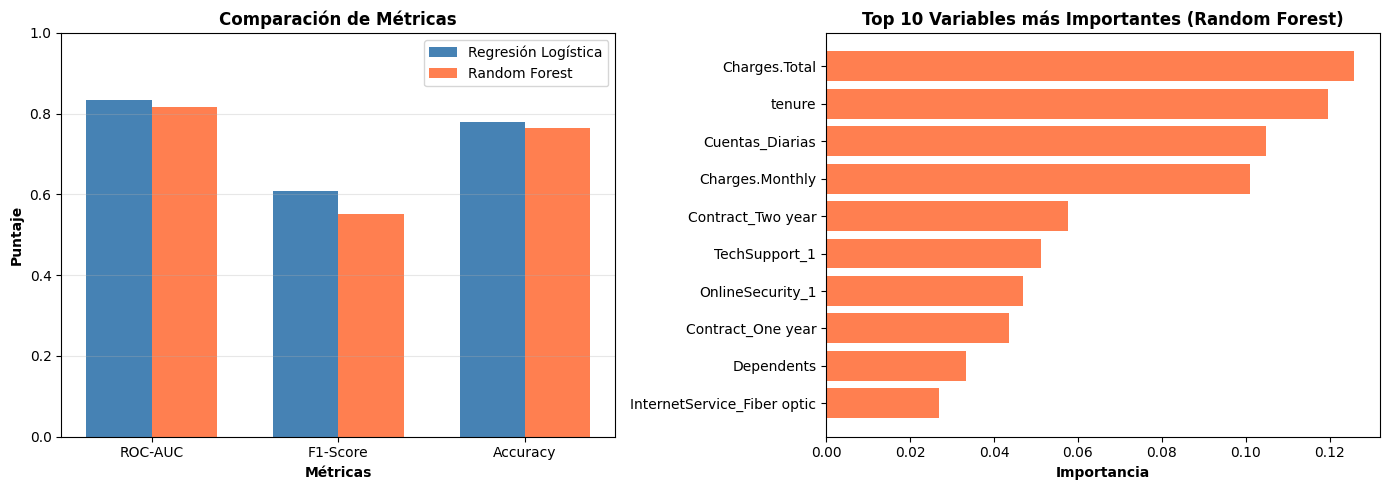

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas = ['ROC-AUC', 'F1-Score', 'Accuracy']
x = np.arange(len(metricas))
width = 0.35

axes[0].bar(x - width/2, comparacion_modelos.loc[0, metricas], width,
            label='Regresión Logística', color='steelblue')
axes[0].bar(x + width/2, comparacion_modelos.loc[1, metricas], width,
            label='Random Forest', color='coral')
axes[0].set_xlabel('Métricas', fontweight='bold')
axes[0].set_ylabel('Puntaje', fontweight='bold')
axes[0].set_title('Comparación de Métricas', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Feature Importance de Random Forest
importancias = pd.DataFrame({
    'feature': X_train_sin_norm.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[1].barh(importancias['feature'], importancias['importance'], color='coral')
axes[1].set_xlabel('Importancia', fontweight='bold')
axes[1].set_title('Top 10 Variables más Importantes (Random Forest)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

 **REGRESIÓN LOGÍSTICA Y KNN - REQUIEREN NORMALIZACIÓN:**

• **Regresión Logística**: Utiliza gradiente descendente para optimizar los coeficientes.
  Si las variables tienen diferentes escalas, las de mayor magnitud dominarán el
  aprendizaje, sesgando los coeficientes.

• **KNN**: Se basa en distancias euclidianas entre puntos. Variables con escalas grandes
  (ej. Charges.Total: 0-8000) tendrán mucho más peso que variables con escalas pequeñas
  (ej. tenure: 0-72), distorsionando completamente los vecinos más cercanos.

 **SOLUCIÓN APLICADA**: StandardScaler (media=0, desviación=1) para todas las variables
   continuas, asegurando que todas contribuyan equitativamente al modelo.

 **RANDOM FOREST - NO REQUIERE NORMALIZACIÓN:**

• Los árboles de decisión dividen el espacio en base a umbrales, no a distancias.
• La escala de las variables no afecta la calidad de las divisiones.
• Por eso entrenamos Random Forest con los datos originales sin escalar.


### MODELO KNN

In [57]:
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_norm, y_train_smote, cv=5, scoring='roc_auc')
    k_scores.append(scores.mean())

# Mejor k
best_k = k_range[np.argmax(k_scores)]
print(f"Mejor valor de k: {best_k} (ROC-AUC: {max(k_scores):.4f})")

# Entrenar con mejor k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_norm, y_train_smote)

# Evaluar
y_pred_knn = knn_model.predict(X_test_norm)
y_pred_proba_knn = knn_model.predict_proba(X_test_norm)[:, 1]

Mejor valor de k: 17 (ROC-AUC: 0.8999)


## Evaluación de los Modelos

Funcion para evaluado modelo

In [68]:
def evaluar_modelo(modelo, X_test, y_test, y_pred, y_pred_proba, nombre_modelo):
    """
    Evalúa un modelo con todas las métricas solicitadas
    """
    print(f"\n{'='*70}")
    print(f" EVALUACIÓN: {nombre_modelo}")
    print(f"{'='*70}")

    # 1. Métricas principales
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print("\nMÉTRICAS PRINCIPALES:")
    print("-" * 40)
    print(f"Exactitud (Accuracy):  {accuracy:.4f}")
    print(f"Precisión:             {precision:.4f}")
    print(f"Recall (Sensibilidad): {recall:.4f}")
    print(f"F1-Score:              {f1:.4f}")
    print(f"ROC-AUC:               {roc_auc:.4f}")

    # 2. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    print("\nMATRIZ DE CONFUSIÓN:")
    print("-" * 40)
    print("                    Predicho")
    print("                No(0)    Sí(1)")
    print(f"Real No(0)     {cm[0,0]:6d}   {cm[0,1]:6d}")
    print(f"Real Sí(1)     {cm[1,0]:6d}   {cm[1,1]:6d}")

    # 3. Classification Report completo
    print("\nCLASSIFICATION REPORT:")
    print("-" * 40)
    print(classification_report(y_test, y_pred, target_names=['No canceló', 'Canceló']))

    # 4. Métricas derivadas de la matriz
    tn, fp, fn, tp = cm.ravel()
    print("\nMÉTRICAS DERIVADAS:")
    print(f"Verdaderos Negativos (bien clasificados no cancelados): {tn}")
    print(f"Falsos Positivos (falsas alarmas): {fp}")
    print(f"Falsos Negativos (cancelaciones no detectadas): {fn}")
    print(f"Verdaderos Positivos (cancelaciones detectadas): {tp}")

    # 5. Tasas importantes
    tpr = tp / (tp + fn)  # Recall / Sensibilidad
    fpr = fp / (fp + tn)  # Tasa de falsos positivos
    print(f"\nTASAS:")
    print(f"Tasa de Verdaderos Positivos (TPR): {tpr:.4f}")
    print(f"Tasa de Falsos Positivos (FPR): {fpr:.4f}")

    return {
        'modelo': nombre_modelo,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

EVALUAR CADA MODELO

In [69]:
resultados = []

resultados.append(evaluar_modelo(
    rl_model, X_test_norm, y_test,
    y_pred_rl, y_pred_proba_rl,
    "Regresión Logística"
))


resultados.append(evaluar_modelo(
    rf_model, X_test_sin_norm, y_test,
    y_pred_rf, y_pred_proba_rf,
    "Random Forest"
))

if 'knn_model' in dir():
    resultados.append(evaluar_modelo(
        knn_model, X_test_norm, y_test,
        y_pred_knn, y_pred_proba_knn,
        "KNN"
    ))




 EVALUACIÓN: Regresión Logística

MÉTRICAS PRINCIPALES:
----------------------------------------
Exactitud (Accuracy):  0.7785
Precisión:             0.5583
Recall (Sensibilidad): 0.6658
F1-Score:              0.6073
ROC-AUC:               0.8326

MATRIZ DE CONFUSIÓN:
----------------------------------------
                    Predicho
                No(0)    Sí(1)
Real No(0)        883      197
Real Sí(1)        125      249

CLASSIFICATION REPORT:
----------------------------------------
              precision    recall  f1-score   support

  No canceló       0.88      0.82      0.85      1080
     Canceló       0.56      0.67      0.61       374

    accuracy                           0.78      1454
   macro avg       0.72      0.74      0.73      1454
weighted avg       0.79      0.78      0.78      1454


MÉTRICAS DERIVADAS:
Verdaderos Negativos (bien clasificados no cancelados): 883
Falsos Positivos (falsas alarmas): 197
Falsos Negativos (cancelaciones no detectadas): 125
Ver

TABLA COMPARATIVA COMPLETA

In [70]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.set_index('modelo')

print("\n" + "="*70)
print(" TABLA COMPARATIVA DE MODELOS")
print("="*70)
print(df_resultados.round(4).to_string())



 TABLA COMPARATIVA DE MODELOS
                     accuracy  precision  recall      f1  roc_auc   tn   fp   fn   tp
modelo                                                                               
Regresión Logística    0.7785     0.5583  0.6658  0.6073   0.8326  883  197  125  249
Random Forest          0.7641     0.5398  0.5615  0.5505   0.8156  901  179  164  210
KNN                    0.7283     0.4826  0.7781  0.5957   0.8091  768  312   83  291


VISUALIZACIÓN COMPARATIVA

<Figure size 1000x600 with 0 Axes>

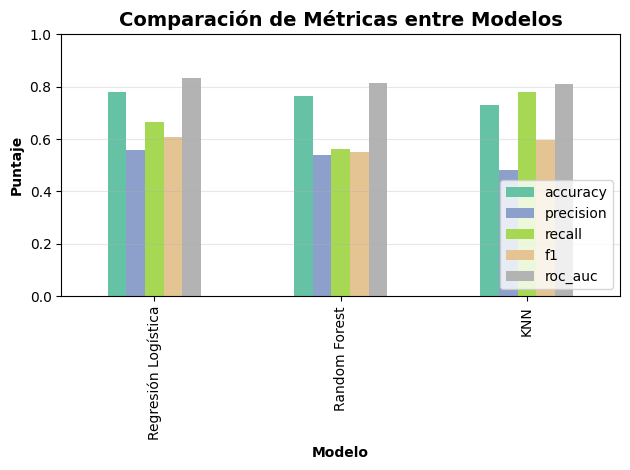

In [72]:
plt.figure(figsize=(10, 6))

metricas_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
df_resultados[metricas_plot].plot(kind='bar', colormap='Set2')

plt.title('Comparación de Métricas entre Modelos', fontweight='bold', fontsize=14)
plt.xlabel('Modelo', fontweight='bold')
plt.ylabel('Puntaje', fontweight='bold')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



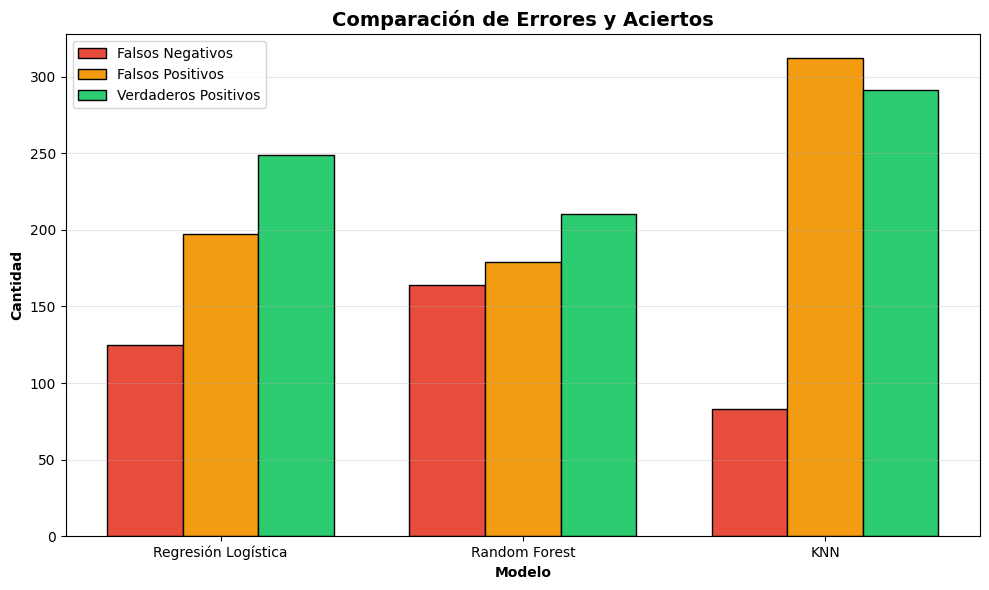

In [73]:
plt.figure(figsize=(10, 6))

x = np.arange(len(df_resultados))
width = 0.25

plt.bar(x - width, [r['fn'] for r in resultados], width,
        label='Falsos Negativos', color='#e74c3c', edgecolor='black')
plt.bar(x, [r['fp'] for r in resultados], width,
        label='Falsos Positivos', color='#f39c12', edgecolor='black')
plt.bar(x + width, [r['tp'] for r in resultados], width,
        label='Verdaderos Positivos', color='#2ecc71', edgecolor='black')

plt.xlabel('Modelo', fontweight='bold')
plt.ylabel('Cantidad', fontweight='bold')
plt.title('Comparación de Errores y Aciertos', fontweight='bold', fontsize=14)
plt.xticks(x, df_resultados.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

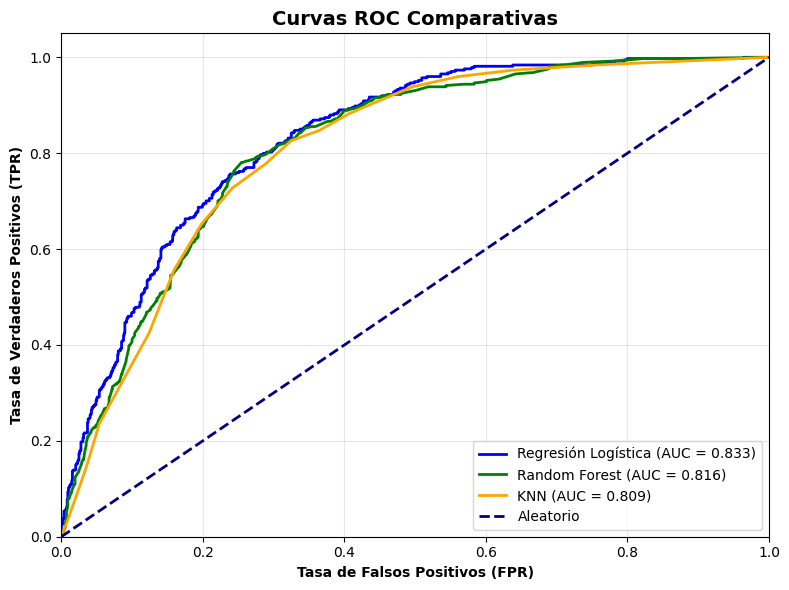

In [74]:
plt.figure(figsize=(8, 6))

for resultado in resultados:
    modelo = resultado['modelo']
    if modelo == 'Regresión Logística':
        y_proba = y_pred_proba_rl
        color = 'blue'
    elif modelo == 'Random Forest':
        y_proba = y_pred_proba_rf
        color = 'green'
    elif modelo == 'KNN':
        y_proba = y_pred_proba_knn
        color = 'orange'

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = resultado['roc_auc']

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{modelo} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontweight='bold')
plt.title('Curvas ROC Comparativas', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

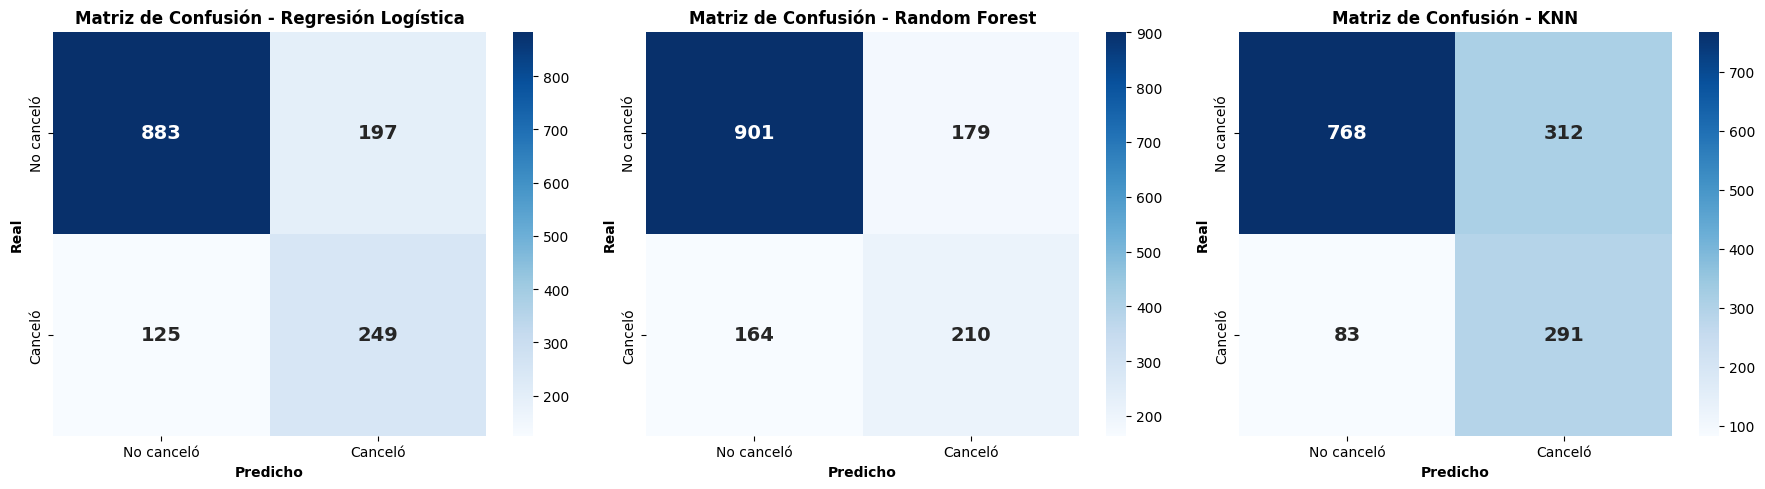

In [76]:
fig, axes = plt.subplots(1, len(resultados), figsize=(6*len(resultados), 5))

if len(resultados) == 1:
    axes = [axes]

for i, resultado in enumerate(resultados):
    cm = np.array([[resultado['tn'], resultado['fp']],
                   [resultado['fn'], resultado['tp']]])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No canceló', 'Canceló'],
                yticklabels=['No canceló', 'Canceló'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    axes[i].set_title(f'Matriz de Confusión - {resultado["modelo"]}',
                      fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicho', fontweight='bold')
    axes[i].set_ylabel('Real', fontweight='bold')

plt.tight_layout()
plt.show()

ANALISIS

In [82]:
mejor_f1 = df_resultados['f1'].idxmax()
mejor_roc = df_resultados['roc_auc'].idxmax()
mejor_recall = df_resultados['recall'].idxmax()
mejor_precision = df_resultados['precision'].idxmax()

print(f"\n RESUMEN DE GANADORES POR MÉTRICA:")
print(f"• Mejor F1-Score: {mejor_f1} ({df_resultados.loc[mejor_f1, 'f1']:.4f})")
print(f"• Mejor ROC-AUC: {mejor_roc} ({df_resultados.loc[mejor_roc, 'roc_auc']:.4f})")
print(f"• Mejor Recall: {mejor_recall} ({df_resultados.loc[mejor_recall, 'recall']:.4f})")
print(f"• Mejor Precisión: {mejor_precision} ({df_resultados.loc[mejor_precision, 'precision']:.4f})")


 RESUMEN DE GANADORES POR MÉTRICA:
• Mejor F1-Score: Regresión Logística (0.6073)
• Mejor ROC-AUC: Regresión Logística (0.8326)
• Mejor Recall: KNN (0.7781)
• Mejor Precisión: Regresión Logística (0.5583)


DETECCIÓN DE OVERFITTING

In [85]:
print("\n **EVALUACIÓN EN TRAIN vs TEST:**")

for resultado in resultados:
    modelo_nombre = resultado['modelo']

    if modelo_nombre == 'Regresión Logística':
        y_train_pred = rl_model.predict(X_train_norm)
        y_train_proba = rl_model.predict_proba(X_train_norm)[:, 1]
        train_f1 = f1_score(y_train_smote, y_train_pred)
        test_f1 = resultado['f1']
    elif modelo_nombre == 'Random Forest':
        y_train_pred = rf_model.predict(X_train_sin_norm)
        y_train_proba = rf_model.predict_proba(X_train_sin_norm)[:, 1]
        train_f1 = f1_score(y_train_smote, y_train_pred)
        test_f1 = resultado['f1']
    elif modelo_nombre == 'KNN' and 'knn_model' in dir():
        y_train_pred = knn_model.predict(X_train_norm)
        y_train_proba = knn_model.predict_proba(X_train_norm)[:, 1]
        train_f1 = f1_score(y_train_smote, y_train_pred)
        test_f1 = resultado['f1']
    else:
        continue

    diferencia = train_f1 - test_f1

    print(f"\n {modelo_nombre}:")
    print(f"   F1-Score Train: {train_f1:.4f}")
    print(f"   F1-Score Test:  {test_f1:.4f}")
    print(f"   Diferencia:     {diferencia:+.4f}")

    if diferencia > 0.1:
        print(f"    POSIBLE OVERFITTING (diferencia > 0.1)")
        print(f"      El modelo aprende demasiado de los datos de entrenamiento")
    elif diferencia < -0.05:
        print(f"    POSIBLE UNDERFITTING (test > train)")
        print(f"      El modelo es demasiado simple")
    else:
        print(f"   GENERALIZACIÓN ADECUADA")



 **EVALUACIÓN EN TRAIN vs TEST:**

 Regresión Logística:
   F1-Score Train: 0.8340
   F1-Score Test:  0.6073
   Diferencia:     +0.2267
    POSIBLE OVERFITTING (diferencia > 0.1)
      El modelo aprende demasiado de los datos de entrenamiento

 Random Forest:
   F1-Score Train: 0.9940
   F1-Score Test:  0.5505
   Diferencia:     +0.4435
    POSIBLE OVERFITTING (diferencia > 0.1)
      El modelo aprende demasiado de los datos de entrenamiento

 KNN:
   F1-Score Train: 0.8439
   F1-Score Test:  0.5957
   Diferencia:     +0.2482
    POSIBLE OVERFITTING (diferencia > 0.1)
      El modelo aprende demasiado de los datos de entrenamiento


ANÁLISIS DE ERRORES POR TIPO

In [87]:
for resultado in resultados:
    fn = resultado['fn']
    fp = resultado['fp']
    total_errores = fn + fp

    print(f"\n{resultado['modelo']}:")
    print(f"   Total errores: {total_errores}")
    print(f"   • Falsos Negativos (cancelaciones no detectadas): {fn} ({fn/total_errores*100:.1f}%)")
    print(f"   • Falsos Positivos (falsas alarmas): {fp} ({fp/total_errores*100:.1f}%)")

    if fn > fp:
        print(f"   El modelo FALLA más en DETECTAR cancelaciones")
        print(f"      → Priorizar estrategias para aumentar RECALL")
    else:
        print(f"   El modelo FALLA más en FALSAS ALARMAS")
        print(f"      → Priorizar estrategias para aumentar PRECISIÓN")


Regresión Logística:
   Total errores: 322
   • Falsos Negativos (cancelaciones no detectadas): 125 (38.8%)
   • Falsos Positivos (falsas alarmas): 197 (61.2%)
   El modelo FALLA más en FALSAS ALARMAS
      → Priorizar estrategias para aumentar PRECISIÓN

Random Forest:
   Total errores: 343
   • Falsos Negativos (cancelaciones no detectadas): 164 (47.8%)
   • Falsos Positivos (falsas alarmas): 179 (52.2%)
   El modelo FALLA más en FALSAS ALARMAS
      → Priorizar estrategias para aumentar PRECISIÓN

KNN:
   Total errores: 395
   • Falsos Negativos (cancelaciones no detectadas): 83 (21.0%)
   • Falsos Positivos (falsas alarmas): 312 (79.0%)
   El modelo FALLA más en FALSAS ALARMAS
      → Priorizar estrategias para aumentar PRECISIÓN


ANALISIS FINAL

In [90]:
# Ponderar métricas para elegir mejor modelo
df_resultados['score_ponderado'] = (
    df_resultados['f1'] * 0.4 +      # Balance general
    df_resultados['recall'] * 0.3 +   # Importancia de detectar cancelaciones
    df_resultados['precision'] * 0.3   # Importancia de no molestar clientes leales
)

mejor_modelo_general = df_resultados['score_ponderado'].idxmax()

**ANÁLISIS DE CONTEXTO DE NEGOCIO:**

Para un problema de cancelación de clientes (churn), debemos considerar:

 **Costo de Falsos Negativos (FN):** Clientes que cancelan y no retenemos.
    → Pérdida de ingresos futuros, costo de adquisición de nuevos clientes.
    
 **Costo de Falsos Positivos (FP):** Clientes leales que reciben ofertas de retención.
    → Gasto en marketing innecesario, posible molestia al cliente.

 **RECOMENDACIÓN BASADA EN RESULTADOS:**

In [96]:
print(f"""

El modelo con mejor balance para este problema es: **{mejor_modelo_general}**

Justificación:
• F1-Score: {df_resultados.loc[mejor_modelo_general, 'f1']:.4f} (balance)
• Recall: {df_resultados.loc[mejor_modelo_general, 'recall']:.4f} (detección)
• Precisión: {df_resultados.loc[mejor_modelo_general, 'precision']:.4f} (confiabilidad)
""")



El modelo con mejor balance para este problema es: **KNN**

Justificación:
• F1-Score: 0.5957 (balance)
• Recall: 0.7781 (detección)
• Precisión: 0.4826 (confiabilidad)



## ANÁLISIS DE IMPORTANCIA DE VARIABLES

### REGRESIÓN LOGÍSTICA - COEFICIENTES

In [97]:
coeficientes = pd.DataFrame({
    'variable': X_train_norm.columns,
    'coeficiente': rl_model.coef_[0]
})

coeficientes['odds_ratio'] = np.exp(coeficientes['coeficiente'])
coeficientes['abs_coef'] = np.abs(coeficientes['coeficiente'])

coeficientes = coeficientes.sort_values('abs_coef', ascending=False)

print("\n TOP 15 VARIABLES MÁS IMPORTANTES (por coeficiente absoluto):")
print("-"*70)
print(coeficientes[['variable', 'coeficiente', 'odds_ratio']].head(15).to_string(index=False))



 TOP 15 VARIABLES MÁS IMPORTANTES (por coeficiente absoluto):
----------------------------------------------------------------------
                      variable  coeficiente  odds_ratio
                  PhoneService    -5.916371    0.002695
   InternetService_Fiber optic    -4.638065    0.009676
               Cuentas_Diarias     3.059708   21.321330
               Charges.Monthly     3.059708   21.321330
             StreamingMovies_1    -2.065305    0.126780
                 StreamingTV_1    -2.046276    0.129215
                        tenure    -1.835651    0.159510
                 TechSupport_1    -1.803106    0.164786
              OnlineSecurity_1    -1.782403    0.168233
                OnlineBackup_1    -1.561056    0.209914
             Contract_Two year    -1.512118    0.220443
                 Charges.Total     1.371911    3.942877
            DeviceProtection_1    -1.296209    0.273567
             MultipleLines_Yes    -1.144255    0.318461
MultipleLines_No phone ser

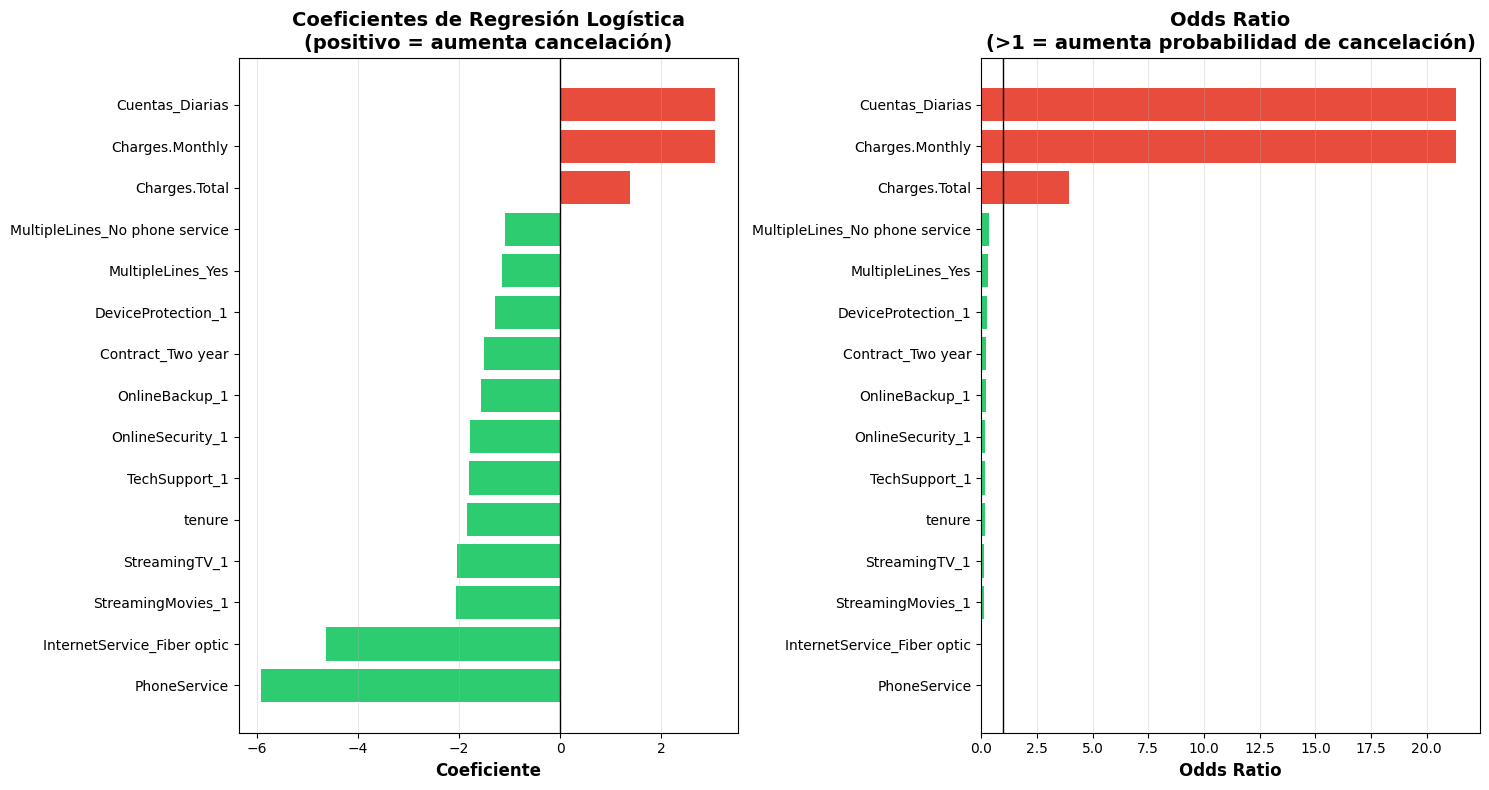


 INTERPRETACIÓN DE ODDS RATIO:
--------------------------------------------------
• Odds Ratio > 1: La variable AUMENTA la probabilidad de cancelación
• Odds Ratio < 1: La variable DISMINUYE la probabilidad de cancelación
• Odds Ratio = 1: La variable no tiene efecto


In [100]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Gráfico de coeficientes
top15_coef = coeficientes.head(15).sort_values('coeficiente', ascending=True)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top15_coef['coeficiente']]
axes[0].barh(top15_coef['variable'], top15_coef['coeficiente'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Coeficiente', fontweight='bold', fontsize=12)
axes[0].set_title('Coeficientes de Regresión Logística\n(positivo = aumenta cancelación)',
                  fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)

# Gráfico de odds ratio
top15_odds = coeficientes.head(15).sort_values('odds_ratio', ascending=True)
axes[1].barh(top15_odds['variable'], top15_odds['odds_ratio'],
             color=['#e74c3c' if x > 1 else '#2ecc71' for x in top15_odds['odds_ratio']])
axes[1].axvline(x=1, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Odds Ratio', fontweight='bold', fontsize=12)
axes[1].set_title('Odds Ratio\n(>1 = aumenta probabilidad de cancelación)',
                  fontweight='bold', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación de odds ratio
print("\n INTERPRETACIÓN DE ODDS RATIO:")
print("-"*50)
print("• Odds Ratio > 1: La variable AUMENTA la probabilidad de cancelación")
print("• Odds Ratio < 1: La variable DISMINUYE la probabilidad de cancelación")
print("• Odds Ratio = 1: La variable no tiene efecto")

### RANDOM FOREST

In [99]:
importancias_rf = pd.DataFrame({
    'variable': X_train_sin_norm.columns,
    'importancia': rf_model.feature_importances_
})

importancias_rf = importancias_rf.sort_values('importancia', ascending=False)

print("\nTOP 15 VARIABLES MÁS IMPORTANTES:")
print("-"*70)
print(importancias_rf.head(15).to_string(index=False))


TOP 15 VARIABLES MÁS IMPORTANTES:
----------------------------------------------------------------------
                             variable  importancia
                        Charges.Total     0.125626
                               tenure     0.119581
                      Cuentas_Diarias     0.104877
                      Charges.Monthly     0.101037
                    Contract_Two year     0.057610
                        TechSupport_1     0.051245
                     OnlineSecurity_1     0.046806
                    Contract_One year     0.043590
                           Dependents     0.033248
          InternetService_Fiber optic     0.026801
                              Partner     0.026429
                       OnlineBackup_1     0.026139
                               gender     0.021510
PaymentMethod_Credit card (automatic)     0.019216
           PaymentMethod_Mailed check     0.018211


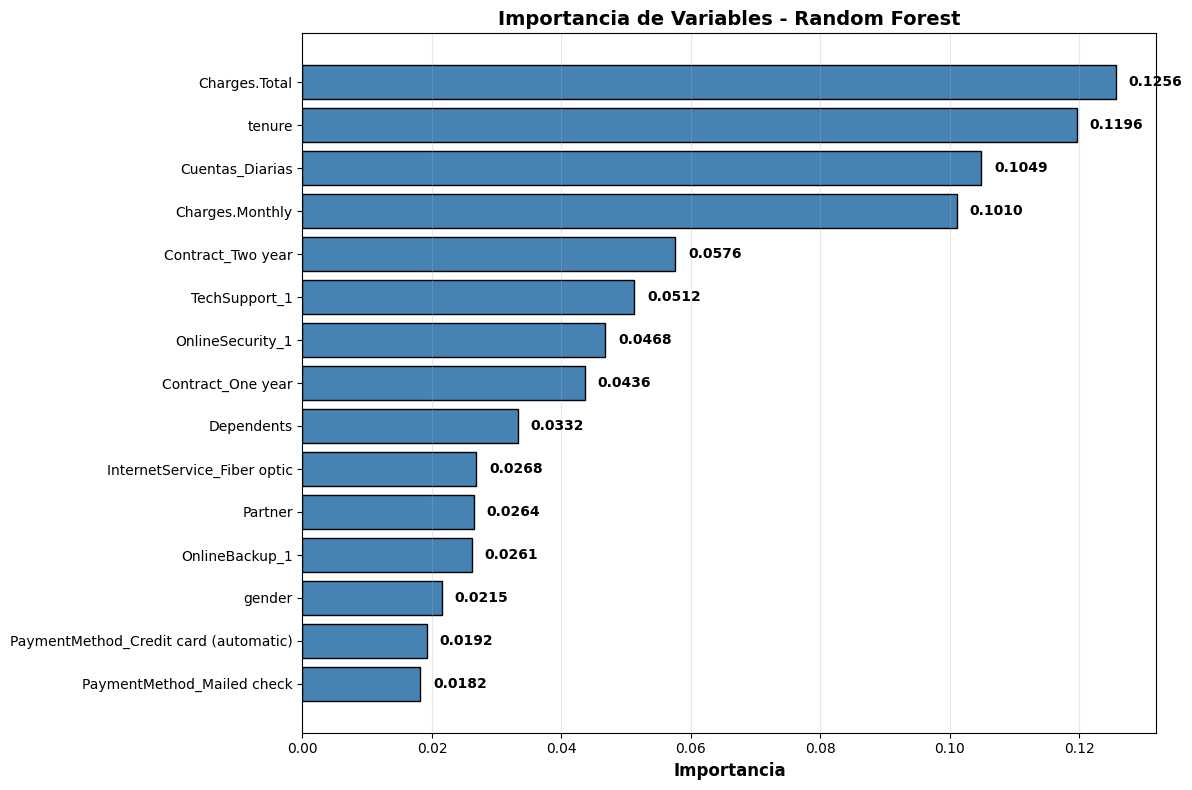


 INTERPRETACIÓN DE IMPORTANCIA:
--------------------------------------------------
• Mide la contribución de cada variable a la reducción de impureza
• Valores más altos = variable más importante para la predicción
• La suma de todas las importancias es 1


In [101]:
# Visualización
plt.figure(figsize=(12, 8))

top15_rf = importancias_rf.head(15).sort_values('importancia', ascending=True)
plt.barh(top15_rf['variable'], top15_rf['importancia'],
         color='steelblue', edgecolor='black')
plt.xlabel('Importancia', fontweight='bold', fontsize=12)
plt.title('Importancia de Variables - Random Forest', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Añadir valores
for i, v in enumerate(top15_rf['importancia']):
    plt.text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN DE IMPORTANCIA:")
print("-"*50)
print("• Mide la contribución de cada variable a la reducción de impureza")
print("• Valores más altos = variable más importante para la predicción")
print("• La suma de todas las importancias es 1")

KNN - VECINOS

In [102]:
std_vars = X_train_norm.std().sort_values(ascending=False)
std_df = pd.DataFrame({
    'variable': std_vars.index,
    'desviacion_std': std_vars.values,
    'impacto_relativo': std_vars.values / std_vars.max()
}).head(15)

print(std_df.to_string(index=False))



                      variable  desviacion_std  impacto_relativo
               Charges.Monthly        1.000058          1.000000
               Cuentas_Diarias        1.000058          1.000000
                        tenure        1.000058          1.000000
                 Charges.Total        1.000058          1.000000
   InternetService_Fiber optic        0.499694          0.499665
                        gender        0.495669          0.495640
              PaperlessBilling        0.490568          0.490539
             MultipleLines_Yes        0.486018          0.485990
                       Partner        0.484611          0.484583
             StreamingMovies_1        0.480365          0.480338
                 StreamingTV_1        0.478759          0.478731
PaymentMethod_Electronic check        0.475794          0.475766
            DeviceProtection_1        0.445666          0.445641
                OnlineBackup_1        0.443340          0.443314
                    Depen

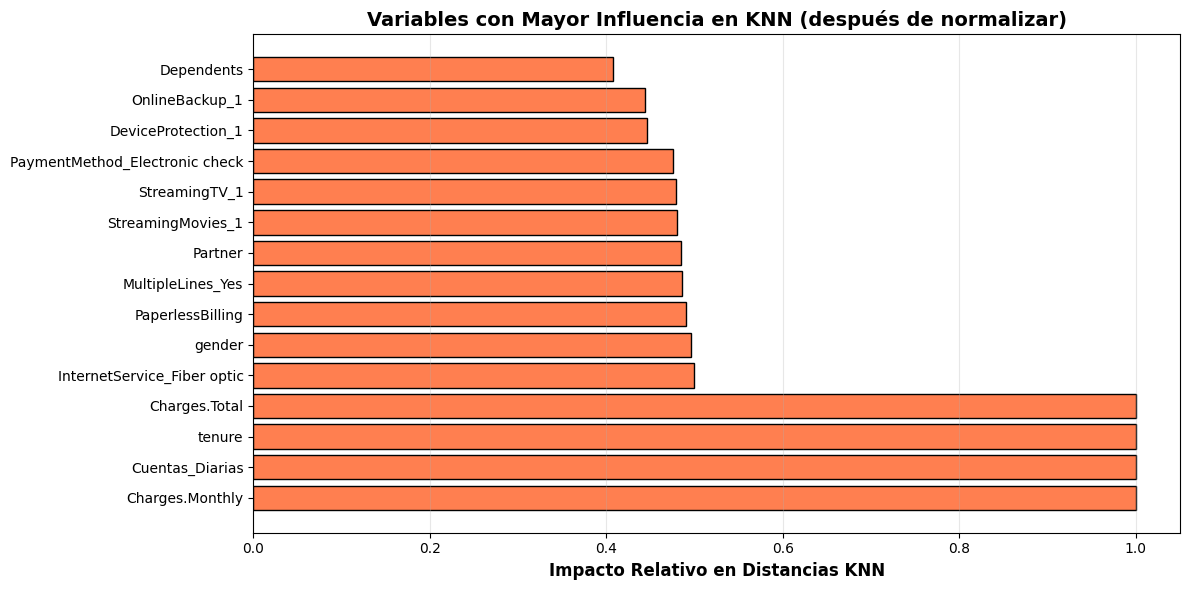


 INTERPRETACIÓN KNN:
--------------------------------------------------
• En KNN, todas las variables tienen el MISMO peso después de normalizar
• Las variables con mayor variabilidad impactan más en las distancias
• La normalización asegura que ninguna variable domine por escala


In [104]:
plt.figure(figsize=(12, 6))
plt.barh(std_df['variable'], std_df['impacto_relativo'],
        color='coral', edgecolor='black')
plt.xlabel('Impacto Relativo en Distancias KNN', fontweight='bold', fontsize=12)
plt.title('Variables con Mayor Influencia en KNN (después de normalizar)',
        fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN KNN:")
print("-"*50)
print("• En KNN, todas las variables tienen el MISMO peso después de normalizar")
print("• Las variables con mayor variabilidad impactan más en las distancias")
print("• La normalización asegura que ninguna variable domine por escala")

CONSISTENCIA

In [109]:
# Para KNN, como no tiene importancia intrínseca, usamos la desviación estándar
std_vars = X_train_norm.std().sort_values(ascending=False)
top10_knn = std_vars.head(10).index.tolist()

# Top 10 de cada modelo
top10_rl = coeficientes.head(10)['variable'].tolist()
top10_rf = importancias_rf.head(10)['variable'].tolist()

print(f"\nTOP 10 - REGRESIÓN LOGÍSTICA:")
for i, var in enumerate(top10_rl, 1):
    print(f"   {i:2d}. {var}")

print(f"\nTOP 10 - RANDOM FOREST:")
for i, var in enumerate(top10_rf, 1):
    print(f"   {i:2d}. {var}")

print(f"\nTOP 10 - KNN (por impacto en distancias):")
for i, var in enumerate(top10_knn, 1):
    print(f"   {i:2d}. {var}")

print("\nVARIABLES CONSISTENTES (en top 10 de al menos 2 modelos):")
print("-"*50)

todas_vars = set(top10_rl + top10_rf + top10_knn)
consistencia = []

for var in todas_vars:
    count = 0
    if var in top10_rl:
        count += 1
    if var in top10_rf:
        count += 1
    if var in top10_knn:
        count += 1

    if count >= 2:
        consistencia.append((var, count))
        modelos = []
        if var in top10_rl:
            modelos.append("RL")
        if var in top10_rf:
            modelos.append("RF")
        if var in top10_knn:
            modelos.append("KNN")
        print(f"   • {var}: presente en {', '.join(modelos)}")

# Variables que aparecen en los 3 modelos (máxima consistencia)
print("\n🏆 VARIABLES CONSENSUS (top 10 en LOS 3 MODELOS):")
print("-"*50)
consensus_3 = [var for var, count in consistencia if count == 3]
if consensus_3:
    for var in consensus_3:
        print(f"   • {var}")
else:
    print("   No hay variables en el top 10 de los 3 modelos simultáneamente")




TOP 10 - REGRESIÓN LOGÍSTICA:
    1. PhoneService
    2. InternetService_Fiber optic
    3. Cuentas_Diarias
    4. Charges.Monthly
    5. StreamingMovies_1
    6. StreamingTV_1
    7. tenure
    8. TechSupport_1
    9. OnlineSecurity_1
   10. OnlineBackup_1

TOP 10 - RANDOM FOREST:
    1. Charges.Total
    2. tenure
    3. Cuentas_Diarias
    4. Charges.Monthly
    5. Contract_Two year
    6. TechSupport_1
    7. OnlineSecurity_1
    8. Contract_One year
    9. Dependents
   10. InternetService_Fiber optic

TOP 10 - KNN (por impacto en distancias):
    1. Charges.Monthly
    2. Cuentas_Diarias
    3. tenure
    4. Charges.Total
    5. InternetService_Fiber optic
    6. gender
    7. PaperlessBilling
    8. MultipleLines_Yes
    9. Partner
   10. StreamingMovies_1

VARIABLES CONSISTENTES (en top 10 de al menos 2 modelos):
--------------------------------------------------
   • tenure: presente en RL, RF, KNN
   • TechSupport_1: presente en RL, RF
   • OnlineSecurity_1: presente en RL, 

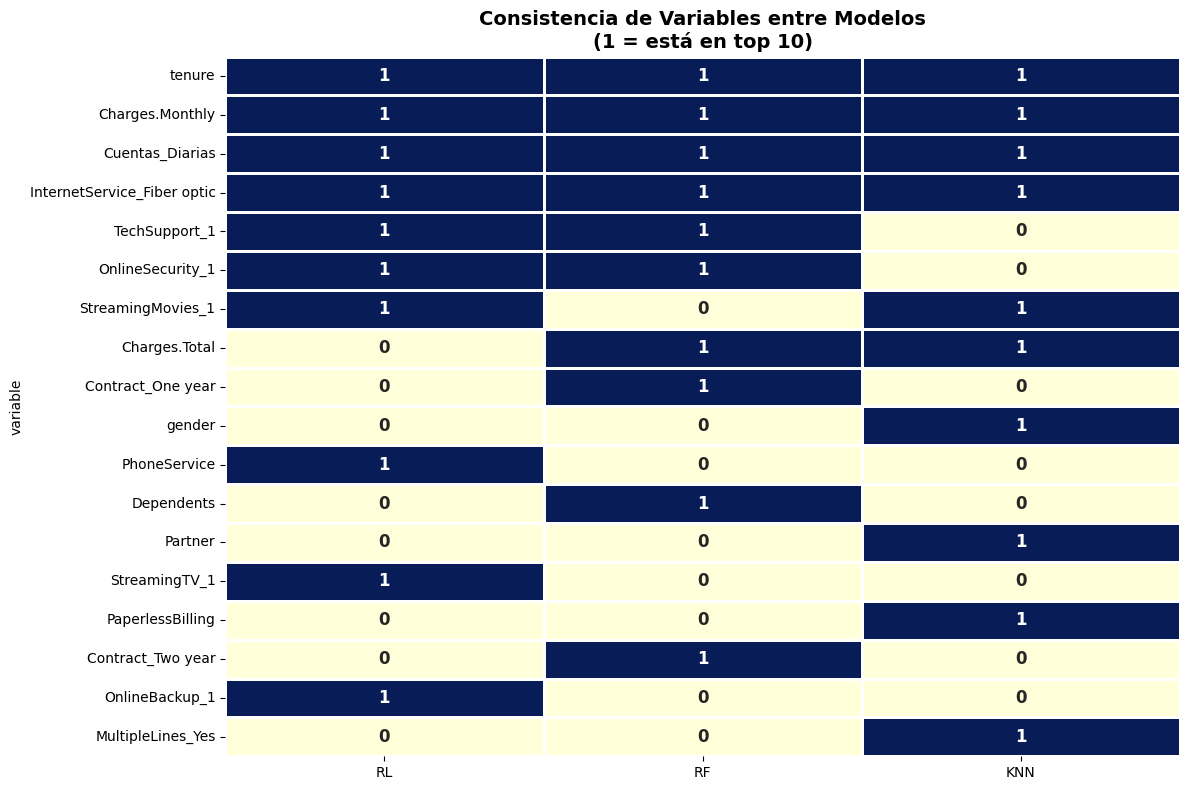

In [110]:
# Matriz de calor de consistencia
fig, ax = plt.subplots(figsize=(12, 8))

# Crear matriz de presencia
modelos = ['RL', 'RF', 'KNN']
presencia = []

for var in todas_vars:
    fila = []
    fila.append(1 if var in top10_rl else 0)
    fila.append(1 if var in top10_rf else 0)
    fila.append(1 if var in top10_knn else 0)
    if sum(fila) >= 1:
        presencia.append([var] + fila)

df_presencia = pd.DataFrame(presencia, columns=['variable', 'RL', 'RF', 'KNN'])
df_presencia = df_presencia.set_index('variable')

# Ordenar por suma de presencia
df_presencia['total'] = df_presencia.sum(axis=1)
df_presencia = df_presencia.sort_values('total', ascending=False).drop('total', axis=1)

# Visualizar
sns.heatmap(df_presencia, annot=True, cmap='YlGnBu', cbar=False,
            linewidths=2, linecolor='white',
            annot_kws={'size': 12, 'fontweight': 'bold'})
plt.title('Consistencia de Variables entre Modelos\n(1 = está en top 10)',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

IMPORTANCIA DE NEGOCIO

In [113]:
# Calcular ranking combinado de variables
ranking_combinado = pd.DataFrame()

# Aportación de cada modelo
rl_rank = coeficientes[['variable', 'abs_coef']].copy()
rl_rank['rl_rank'] = rl_rank['abs_coef'].rank(ascending=False)
rl_rank = rl_rank[['variable', 'rl_rank']]

rf_rank = importancias_rf[['variable', 'importancia']].copy()
rf_rank['rf_rank'] = rf_rank['importancia'].rank(ascending=False)
rf_rank = rf_rank[['variable', 'rf_rank']]

knn_rank = pd.DataFrame({
    'variable': std_vars.index,
    'knn_impacto': std_vars.values
})
knn_rank['knn_rank'] = knn_rank['knn_impacto'].rank(ascending=False)

# Combinar rankings
ranking = rl_rank.merge(rf_rank, on='variable', how='outer')
ranking = ranking.merge(knn_rank, on='variable', how='outer')
ranking = ranking.fillna(1000)  # Valor alto para variables no rankeadas

# Calcular ranking promedio (menor = mejor)
ranking['rank_promedio'] = (ranking['rl_rank'] + ranking['rf_rank'] + ranking['knn_rank']) / 3
ranking = ranking.sort_values('rank_promedio').head(15)

print("\n RANKING COMBINADO DE VARIABLES (promedio de 3 modelos):")
print("-"*70)
print(ranking[['variable', 'rl_rank', 'rf_rank', 'knn_rank', 'rank_promedio']].round(1).to_string(index=False))

# Top variables de negocio
top_vars_negocio = ranking.head(8)['variable'].tolist()



 RANKING COMBINADO DE VARIABLES (promedio de 3 modelos):
----------------------------------------------------------------------
                   variable  rl_rank  rf_rank  knn_rank  rank_promedio
            Cuentas_Diarias      3.0      3.0       1.5            2.5
            Charges.Monthly      4.0      4.0       1.5            3.2
                     tenure      7.0      2.0       3.0            4.0
              Charges.Total     12.0      1.0       4.0            5.7
InternetService_Fiber optic      2.0     10.0       5.0            5.7
              TechSupport_1      8.0      6.0      17.0           10.3
           OnlineSecurity_1      9.0      7.0      16.0           10.7
          Contract_Two year     11.0      5.0      19.0           11.7
             OnlineBackup_1     10.0     12.0      14.0           12.0
          StreamingMovies_1      5.0     22.0      10.0           12.3
              StreamingTV_1      6.0     24.0      11.0           13.7
          MultipleL

In [114]:

print(f"""
 **FACTORES CRÍTICOS DE CANCELACIÓN (TOP 8 - CONSENSO MULTIMODELO):**

1. **{top_vars_negocio[0]}** - Variable más predictiva (consenso)
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[0]['rl_rank'] < 20, ranking.iloc[0]['rf_rank'] < 20, ranking.iloc[0]['knn_rank'] < 20]) if v])}
   • Impacto: Muy alto
   • Acción sugerida: [Interpretar según contexto]

2. **{top_vars_negocio[1]}** - Segundo factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[1]['rl_rank'] < 20, ranking.iloc[1]['rf_rank'] < 20, ranking.iloc[1]['knn_rank'] < 20]) if v])}
   • Impacto: Alto
   • Acción sugerida: [Interpretar según contexto]

3. **{top_vars_negocio[2]}** - Tercer factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[2]['rl_rank'] < 20, ranking.iloc[2]['rf_rank'] < 20, ranking.iloc[2]['knn_rank'] < 20]) if v])}
   • Impacto: Alto
   • Acción sugerida: [Interpretar según contexto]

4. **{top_vars_negocio[3]}** - Cuarto factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[3]['rl_rank'] < 20, ranking.iloc[3]['rf_rank'] < 20, ranking.iloc[3]['knn_rank'] < 20]) if v])}
   • Impacto: Moderado-Alto

5. **{top_vars_negocio[4]}** - Quinto factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[4]['rl_rank'] < 20, ranking.iloc[4]['rf_rank'] < 20, ranking.iloc[4]['knn_rank'] < 20]) if v])}
   • Impacto: Moderado

6. **{top_vars_negocio[5]}** - Sexto factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[5]['rl_rank'] < 20, ranking.iloc[5]['rf_rank'] < 20, ranking.iloc[5]['knn_rank'] < 20]) if v])}
   • Impacto: Moderado

7. **{top_vars_negocio[6]}** - Séptimo factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[6]['rl_rank'] < 20, ranking.iloc[6]['rf_rank'] < 20, ranking.iloc[6]['knn_rank'] < 20]) if v])}
   • Impacto: Moderado

8. **{top_vars_negocio[7]}** - Octavo factor
   • Presente en: {', '.join([m for m, v in zip(['RL', 'RF', 'KNN'], [ranking.iloc[7]['rl_rank'] < 20, ranking.iloc[7]['rf_rank'] < 20, ranking.iloc[7]['knn_rank'] < 20]) if v])}
   • Impacto: Moderado
""")






 **FACTORES CRÍTICOS DE CANCELACIÓN (TOP 8 - CONSENSO MULTIMODELO):**

1. **Cuentas_Diarias** - Variable más predictiva (consenso)
   • Presente en: RL, RF, KNN
   • Impacto: Muy alto
   • Acción sugerida: [Interpretar según contexto]

2. **Charges.Monthly** - Segundo factor
   • Presente en: RL, RF, KNN
   • Impacto: Alto
   • Acción sugerida: [Interpretar según contexto]

3. **tenure** - Tercer factor
   • Presente en: RL, RF, KNN
   • Impacto: Alto
   • Acción sugerida: [Interpretar según contexto]

4. **Charges.Total** - Cuarto factor
   • Presente en: RL, RF, KNN
   • Impacto: Moderado-Alto

5. **InternetService_Fiber optic** - Quinto factor
   • Presente en: RL, RF, KNN
   • Impacto: Moderado

6. **TechSupport_1** - Sexto factor
   • Presente en: RL, RF, KNN
   • Impacto: Moderado

7. **OnlineSecurity_1** - Séptimo factor
   • Presente en: RL, RF, KNN
   • Impacto: Moderado

8. **Contract_Two year** - Octavo factor
   • Presente en: RL, RF, KNN
   • Impacto: Moderado



Clasificar por tipo de variable

In [116]:
servicios = [v for v in top_vars_negocio if any(x in v for x in ['Online', 'Backup', 'Protection', 'Support', 'Streaming', 'MultipleLines', 'InternetService'])]
contrato = [v for v in top_vars_negocio if 'Contract' in v]
pago = [v for v in top_vars_negocio if 'Payment' in v]
demograficas = [v for v in top_vars_negocio if v in ['tenure', 'SeniorCitizen', 'gender', 'Partner', 'Dependents']]
cargos = [v for v in top_vars_negocio if 'Charges' in v or 'Cuentas' in v]

if servicios:
    print(f"\n  SERVICIOS CONTRATADOS:")
    for v in servicios:
        print(f"   • {v}")
if contrato:
    print(f"\n TIPO DE CONTRATO:")
    for v in contrato:
        print(f"   • {v}")
if pago:
    print(f"\n MÉTODO DE PAGO:")
    for v in pago:
        print(f"   • {v}")
if cargos:
    print(f"\n VARIABLES DE GASTO:")
    for v in cargos:
        print(f"   • {v}")
if demograficas:
    print(f"\n VARIABLES DEMOGRÁFICAS:")
    for v in demograficas:
        print(f"   • {v}")



  SERVICIOS CONTRATADOS:
   • InternetService_Fiber optic
   • TechSupport_1
   • OnlineSecurity_1

 TIPO DE CONTRATO:
   • Contract_Two year

 VARIABLES DE GASTO:
   • Cuentas_Diarias
   • Charges.Monthly
   • Charges.Total

 VARIABLES DEMOGRÁFICAS:
   • tenure


RECOMENDACIONES ESPECIFICAS

In [117]:

print("""
 **FACTORES DE RIESGO (aumentan probabilidad de cancelación):**
""")
factores_riesgo = coeficientes[coeficientes['coeficiente'] > 0].head(5)
for _, row in factores_riesgo.iterrows():
    print(f"   • {row['variable']}: +{row['coeficiente']:.3f} (coeficiente)")

print("""
**FACTORES PROTECTORES (disminuyen probabilidad de cancelación):**
""")

factores_protectores = coeficientes[coeficientes['coeficiente'] < 0].head(5)
for _, row in factores_protectores.iterrows():
    print(f"   • {row['variable']}: {row['coeficiente']:.3f} (coeficiente)")


 **FACTORES DE RIESGO (aumentan probabilidad de cancelación):**

   • Cuentas_Diarias: +3.060 (coeficiente)
   • Charges.Monthly: +3.060 (coeficiente)
   • Charges.Total: +1.372 (coeficiente)
   • DeviceProtection_No internet service: +0.649 (coeficiente)
   • TechSupport_No internet service: +0.649 (coeficiente)

**FACTORES PROTECTORES (disminuyen probabilidad de cancelación):**

   • PhoneService: -5.916 (coeficiente)
   • InternetService_Fiber optic: -4.638 (coeficiente)
   • StreamingMovies_1: -2.065 (coeficiente)
   • StreamingTV_1: -2.046 (coeficiente)
   • tenure: -1.836 (coeficiente)


RECOMENDACION ESTRATÉGICAS:

1. **Segmentación de clientes** basada en las variables top:
   • Clientes de alto riesgo (según factores de riesgo)
   • Clientes leales (según factores protectores)

2. **Estrategias de retención diferenciadas:**
   • Para clientes con factores de riesgo: intervención temprana
   • Para clientes con factores protectores: programas de lealtad

3. **Monitoreo continuo** de las variables clave:
   • Establecer alertas cuando clientes muestren cambios en estas variables
   • Seguimiento trimestral de la evolución

4. **Pruebas A/B** para validar intervenciones:
   • Grupo control vs grupo con ofertas personalizadas
   • Medir reducción en tasa de cancelación


VISUALIZACION FINAL

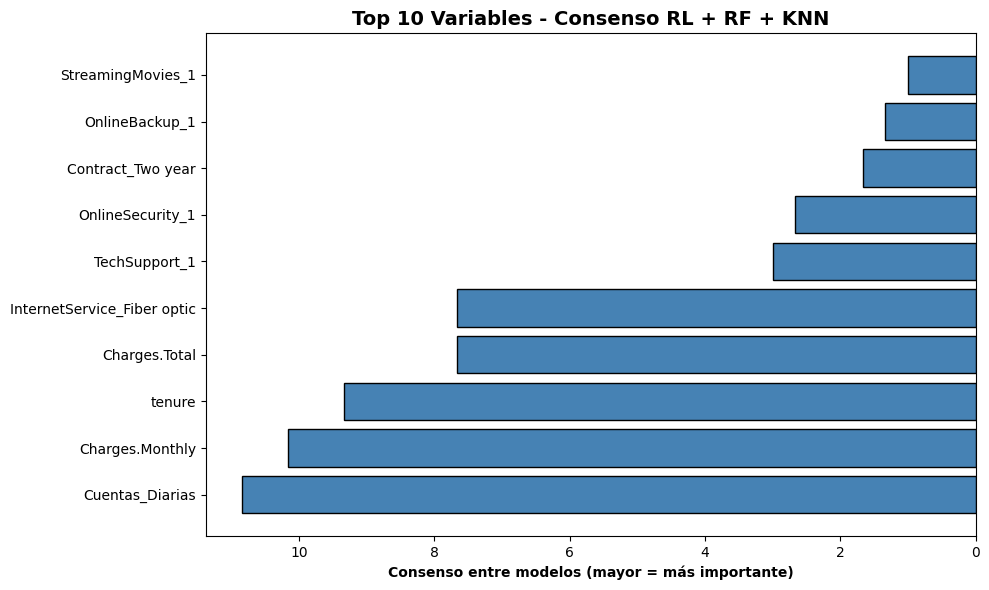

In [118]:

fig, ax = plt.subplots(figsize=(10, 6))

top_consenso = ranking.head(10).sort_values('rank_promedio', ascending=True)
bars = ax.barh(range(len(top_consenso)), top_consenso['rank_promedio'].max() - top_consenso['rank_promedio'] + 1,
               color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_consenso)))
ax.set_yticklabels(top_consenso['variable'])
ax.set_xlabel('Consenso entre modelos (mayor = más importante)', fontweight='bold')
ax.set_title('Top 10 Variables - Consenso RL + RF + KNN', fontweight='bold', fontsize=14)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

GUARDAR RESULTADOS EN CSV

In [122]:

os.makedirs('resultados_churn', exist_ok=True)
df_resultados.to_csv('resultados_churn/metricas_modelos.csv', index=True)
coeficientes.to_csv('resultados_churn/rl_coeficientes.csv', index=False)
importancias_rf.to_csv('resultados_churn/rf_importancia.csv', index=False)

# KNN
if 'knn_model' in dir():
    std_df = pd.DataFrame({
        'variable': X_train_norm.columns,
        'desviacion_std': X_train_norm.std().values,
        'impacto_relativo': X_train_norm.std().values / X_train_norm.std().max()
    }).sort_values('desviacion_std', ascending=False)
    std_df.to_csv('resultados_churn/knn_impacto.csv', index=False)

# Ranking combinado
ranking_completo = ranking[['variable', 'rl_rank', 'rf_rank', 'knn_rank', 'rank_promedio']].sort_values('rank_promedio')
ranking_completo.to_csv('resultados_churn/ranking_combinado.csv', index=False)

# Matrices de confusión
cm_data = []
for r in resultados:
    cm_data.append({
        'Modelo': r['modelo'],
        'TN': r['tn'],
        'FP': r['fp'],
        'FN': r['fn'],
        'TP': r['tp'],
        'Total_Errores': r['fn'] + r['fp'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'ROC_AUC': r['roc_auc']
    })
pd.DataFrame(cm_data).to_csv('resultados_churn/matrices_confusion.csv', index=False)